# Visual learning and unsupervised plasticity with large-scale neural recordings
#### data from [Zhong et al, 2025](https://www.nature.com/articles/s41586-025-09180-y)

This dataset consists of simultaneous neural recordings from over 50,000 neurons, while mice perform a visual discrimination task in virtual reality. Mice are rewarded with water when they lick in the correct corridor.

Recordings are made with a two-photon large field of view mesoscope, spanning primary visual cortex as well as higher-order visual areas (medial, anterior, lateral).

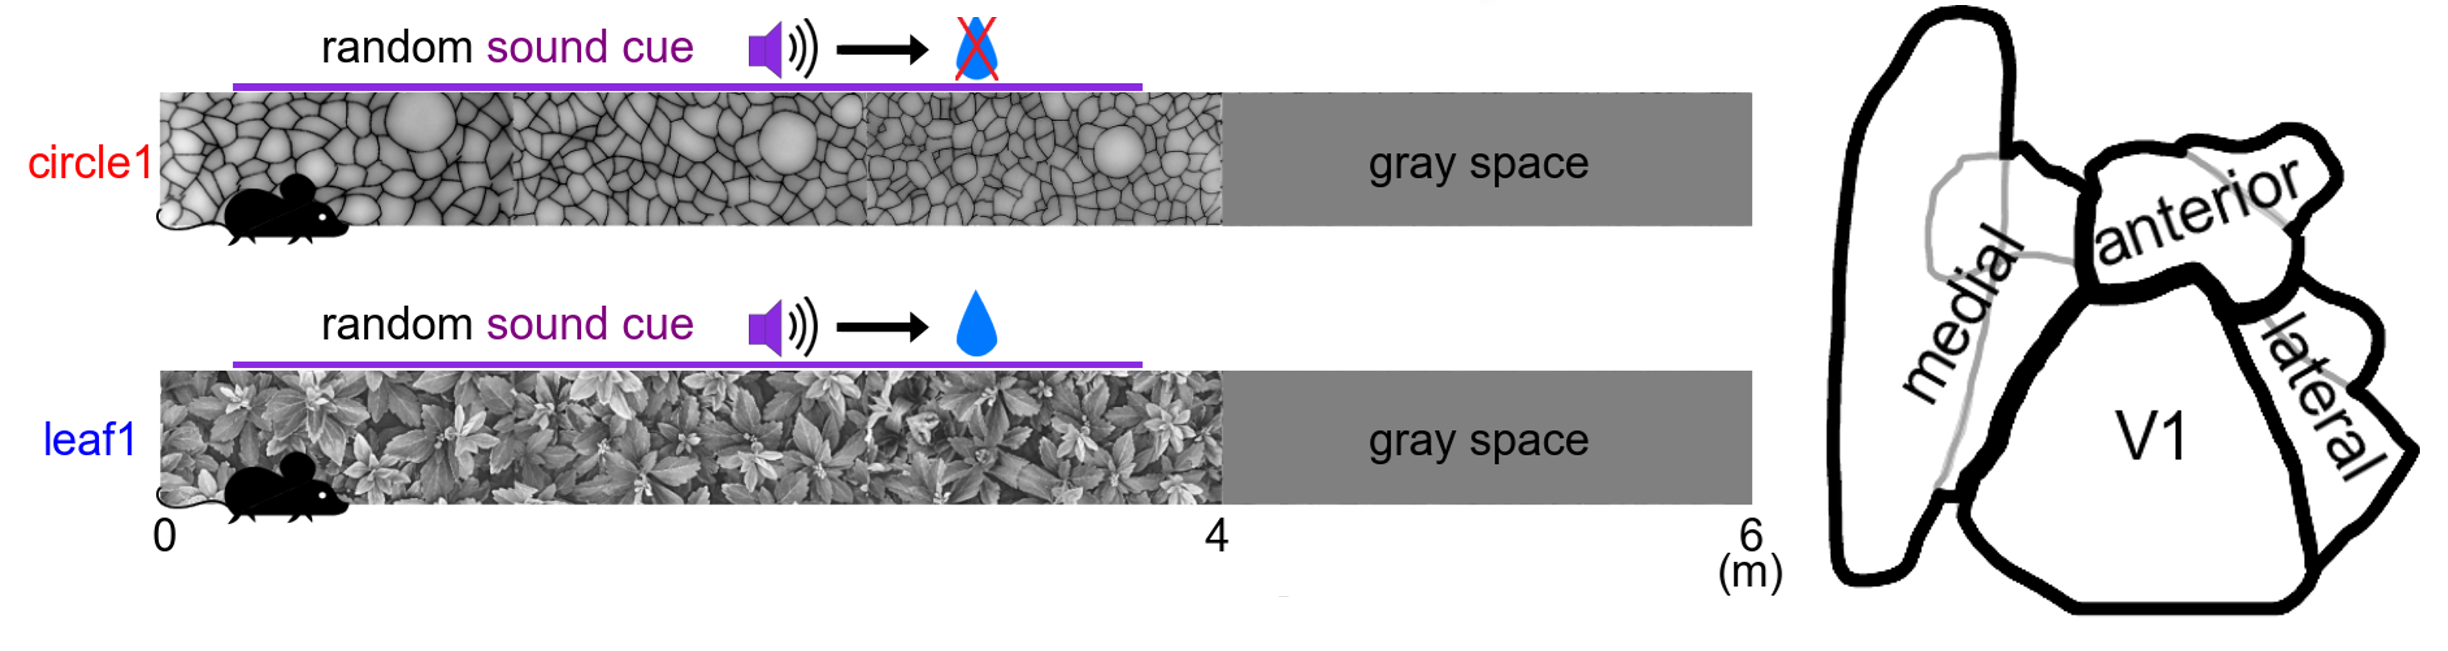

Recording are made before and after training ("train1" session), as well as with new stimuli ("test1" session). The new stimuli are similar, but not identical to the trained ones. Mice likely perceive these as novel.  

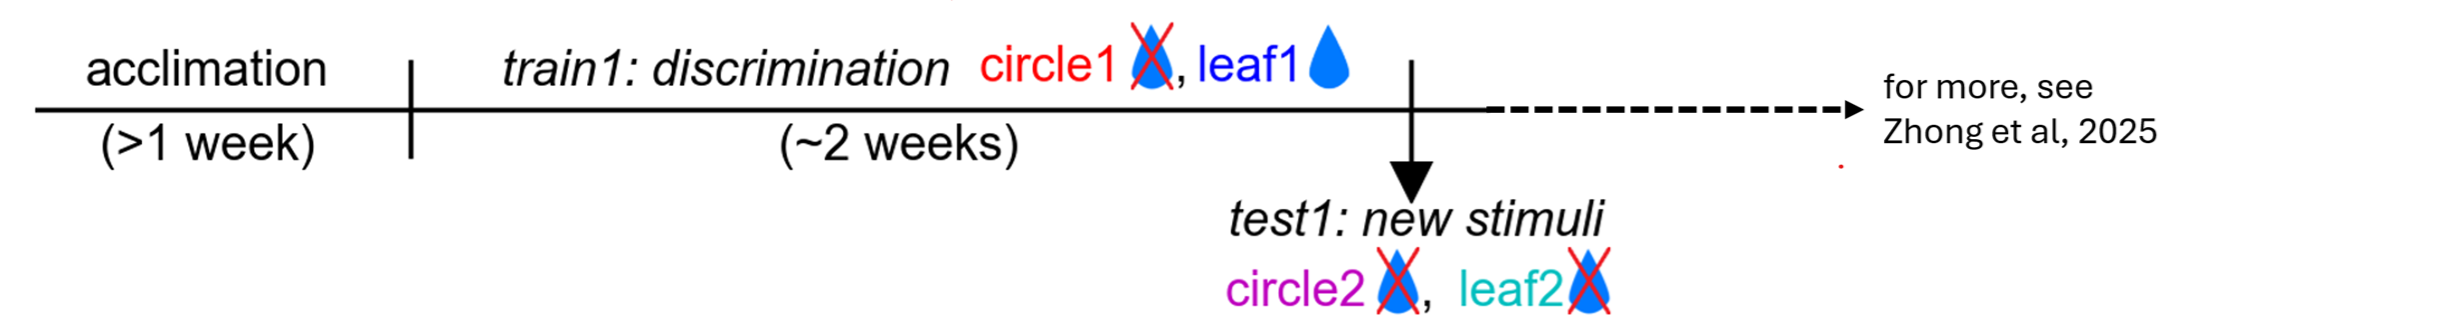

In [ ]:
# @title Import packages
from pathlib import Path
import json
import requests
import os
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# @title Data loading and imports

# set path for data
root = r'/content'
Path(root).mkdir(exist_ok=True)
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

# files required for this project: 'VR2_2021_03_20_1_example_raw_spk.npy'; 'VR2_2021_03_20_1_SVD_dec.npy'; 'VR2_2021_03_20_trans.npz'; 'VR2_2021_04_06_1_SVD_dec.npy'; 'VR2_2021_04_06_trans.npz';
#        'TX105_2022_10_08_2_SVD_dec.npy'; 'TX105_2022_10_08_trans.npz'; 'TX105_2022_10_19_2_SVD_dec.npy'; 'TX105_2022_10_19_trans.npz'
#        'Beh_sup_train1_before_learning.npy'; 'Beh_sup_train1_after_learning.npy'; 'Beh_unsup_train1_before_learning.npy'; 'Beh_unsup_train1_after_learning.npy'
sup_bef = 'VR2' #example mouse before supervised learning
sup_aft = 'VR2' #example mouse after supervised learning
unsup_bef = 'TX105' #example mouse before supervised learning
unsup_aft = 'TX105' #example mouse after supervised learning

# download files from Figshare
file_ID = [54866153, 54866354, 54184211, 54866333, 54184214, 54866237, 54184028, 54866150, 54184031, 54183863, 54183860, 54183914, 54183917] # IDs of files

BASE_URL = '....'
r = requests.get(BASE_URL + '/articles/' + str(28811129)) # 28811129 is the ID of the whole dataset
file_metadata = json.loads(r.text)
for file in file_metadata['files']:
  if file['id'] in file_ID: # only download files included in file_ID
    fn = os.path.join(root, file['name'])
    if not os.path.isfile(fn):
      response = requests.get(BASE_URL + '/file/download/' + str(file['id']))
      open(fn, 'wb').write(response.content)
    print(fn)

/content/Zhong_et_al_2025/Beh_sup_train1_after_learning.npy
/content/Zhong_et_al_2025/Beh_sup_train1_before_learning.npy
/content/Zhong_et_al_2025/Beh_unsup_train1_after_learning.npy
/content/Zhong_et_al_2025/Beh_unsup_train1_before_learning.npy
/content/Zhong_et_al_2025/TX105_2022_10_08_trans.npz
/content/Zhong_et_al_2025/TX105_2022_10_19_trans.npz
/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz
/content/Zhong_et_al_2025/VR2_2021_04_06_trans.npz
/content/Zhong_et_al_2025/TX105_2022_10_19_2_SVD_dec.npy
/content/Zhong_et_al_2025/VR2_2021_03_20_1_example_raw_spk.npy
/content/Zhong_et_al_2025/TX105_2022_10_08_2_SVD_dec.npy
/content/Zhong_et_al_2025/VR2_2021_04_06_1_SVD_dec.npy
/content/Zhong_et_al_2025/VR2_2021_03_20_1_SVD_dec.npy


# Definition of variables in Behavior data
Variables inside `beh`:
*   `beh['ntrials']`: number of trials
*   `beh['trInd']`: trials index
*   `beh['trInd_odd']`: the index of odd trials
*   `beh['trInd_even']`: the index of even trials
*   `beh['Trial_start_time']`: time when animal enters each corridor
*   `beh['Trial_end_time']`: time when animal ran out each corridor
*   `beh['stim_id']`: ID of stimuli;  0:circle1, 1:circle2, 2:leaf1, 3:leaf2 4:leaf3, 5:leaf1_swap1, 6:leaf1_swap2
*   `beh['SubjMove']`: running information
  *   `beh['SubjMove']['SubjMTime']`: time stamps of running
  *   `beh['SubjMove']['SubjMPos']`: position inside corridor
  *   `beh['SubjMove']['SubjMPosCum']`: cumulative position inside VR
  *   `beh['SubjMove']['SubjMDistCum']`: almost identical with `beh['SubjMove']['SubjMPosCum']`
  *   `beh['SubjMove']['SubjM_pitch']`: pitch (forward) running speed
  *   `beh['SubjMove']['SubjM_roll']`: roll direction running speed  
  *   `beh['SubjMove']['SubjM_yaw']`: yaw direction running speed    
  *   `beh['SubjMove']['SubjM_pitch_cum']`: total running distance. Note that it is not the same as `beh['SubjMove']['SubjMPosCum']` given that we only move the VR and with a constant speed when `beh['SubjMove']['SubjM_pitch']` pass a threshold
*   `beh['Gray_space_time']`: time when animal entered the gray space
*   `beh['SoundPos']`: position of sound cue
*   `beh['SoundTime']`: time of sound cue
*   `beh['SoundTimeDelay']`: time of sound cue with a delay, if delay=0, then it is the same as `beh['SoundTime']`
*   `beh['RewTime']`: time of reward delivery, these numbers only valid in the reward corridor.
*   `beh['RewPos']`: position of reward delivery, with NaN in the non-reward corridor.
*   `beh['isRew']`: boolean value indicating if the trial is a reward trial.
*   `beh['WallType']`: category of stimuli, but please ignore this one since it doesn't apply to our experiments
*   `beh['WallIsProbe']`: whether is a catch trial, but please ignore this one
*   `beh['WallName']`: name of stimuli in each corridor
*   `beh['UniqWalls']`: name of stimuli in the whole session
*   `beh['LickTrind']`: trial stamp of each lick
*   `beh['LickTime']`: time stamp of each lick
*   `beh['LickPos']`: positional stamp of each lick
*   `beh['Lick_wallName']`: corresponding stimulus of each lick
*   `beh['VRpos']`: position inside VR
*   `beh['VRposCum']`: cumulative position inside VR
*   `beh['VRposTime']`: time stamp for `beh['VRpos']` and `beh['VRposCum']`
*   `beh['ft']`: time stamp for each neural frame
*   `beh['ft_trInd']`: trial stamp for each neural frame, NaN means outside the behavior recorded
*   `beh['ft_trInd_odd']`: neural frames from odd trials
*   `beh['ft_trInd_even']`: neural frames from even trials
*   `beh['ft_Pos']`: position inside VR for each neural frame
*   `beh['ft_PosCum']`: culculative position inside VR for each neural frame
*   `beh['ft_move']`: the differences between each frame of `beh['ft_PosCum']`
*   `beh['ft_isMoving']`: boolean value for `beh['ft_move']>0`
*   `beh['ft_GraySpc']`: boolean value indicating if animals is inside gray space
*   `beh['ft_CorrSpc']`: boolean value indicating if animals is inside texture area
*   `beh['ft_WallID']`: the corridor each neural frame belongs to
*   `beh['ft_RunCum']`: cumulative running distance for each neural frame
*   `beh['ft_RunSpeed']`: running speed for each neural frame
*   `beh['RunFr']`: same as `beh['ft_RunSpeed']`
*   `beh['run_pos']`: running speed interpolated into trials * positions
*   `beh['RewardFr']`: neural frame when reward was delivered, length=ntrials, NaN means trial without reward being delivered
*   `beh['StartFr']`: neural frame when animal enter each corridor
*   `beh['GrayFr']`: neural frame when animal enter gray space
*   `beh['EndFr']`: neural frame when animal ran out of a corridor
*   `beh['LickFr']`: neural frame when animal licked
*   `beh['SoundFr']`: neural frame when sound cue was delivered
*   `beh['SoundDelayFr']`: neural frame when sound cue was delivered + a delay, if delay=0, then it is the same as `beh['SoundFr']`
*   `beh['SoundDelPos']`: position inside a corridor, corresponding to `beh['SoundDelayFr']`
*   `beh['BefCueFr']`: boolean values indicating neural frames after entered corridor but before cue was delivered
*   `beh['AftCueFr']`: boolean values indicating neural frames after cue was delivered
*   `beh['TrialStim']`: stimulus name of each trial
*   `beh['StimTrial']`: subfields are trial index of each stimulus
*   `beh['StimFrame']`: subfields are neural frame index of each stimulus

Below are some settings:
*   `beh['Corridor_Length']`: length of the corridor
*   `beh['Gray_Space_length']`: length of gray space
*   `beh['Texture_Length']`: length of texture area
*   `beh['Reward_Mode']`: reward mode of experiment, either passive reward in which reward was delivered without lick  or active reward in which reward was triggered be licking
*   `beh['Reward_Delay_ms']`: delay time for reward, this is a setting. Find the actually reward time in `beh['RewTime']`

In [ ]:
# @title Loading raw data from 1000 neurons
example_raw_data = np.load(os.path.join(root, sup_bef + '_example_raw_spk.npy'))
nfrs = example_raw_data.shape[1]
print('Shape of example_raw_data (neurons * frames):', example_raw_data.shape)

Shape of example_raw_data (neurons * frames): (1000, 24298)


In [ ]:
# @title Load behavioral data
import pandas as pd
beh = np.load(os.path.join(root, 'Beh_sup_train1_before_learning.npy'), allow_pickle=1).item()[sup_bef]
print(beh.keys())

df = pd.json_normalize(beh)

# df = pd.DataFrame(data=beh)
#print(f'beh: {df}')
stim_id = beh['stim_id'] # 0:circle1, 1:circle2, 2:leaf1, 3:leaf2, 4:leaf3

ntrials, uniqW, WallN = beh['ntrials'], beh['UniqWalls'], beh['WallName']
print(f'ntrials: {ntrials}')
print(f'uniqW: {uniqW} , shape of uniqW {WallN.shape}')
print(f'WallN: {WallN}')

SoundPos = beh['SoundPos']

lick_fr = beh['LickFr'] # frame with lick
#print(f'lick_fr: {lick_fr}')

cue_fr = beh['SoundFr'] # frame with cue
#print(f'cue_fr: {cue_fr}')

stim_fr = beh['ft_WallID'] # trial stimulus of each frame
print(f'stim_fr: {stim_fr}')

pos_fr = beh['ft_Pos'] # position of each frame inside corridor
print(f'pos_fr: {pos_fr}')

cum_pos_fr = beh['ft_PosCum']
print(f'cum_pos_fr: {cum_pos_fr}')

VR_move = beh['ft_move']>0 # frames with virtual scene moving
print(f'VR_move: {VR_move}')

name_stim1 = uniqW[stim_id==2][0] # name of stimulus 1; rewarded stimulus (leaf1) for supervised experiment
name_stim2 = uniqW[stim_id==0][0] # name of stimulus 2; non-rewarded stimulus (circle1) for supervised experiment
stim1_tr = WallN==name_stim1
stim2_tr = WallN==name_stim2

# get index of frame within stimulus 1 (0-40 is within texture area, 40-60 is gray space)
stim1_idx = (stim_fr==name_stim1) & (pos_fr<40)
stim2_idx = (stim_fr==name_stim2) & (pos_fr<40)
gray_idx = ((stim_fr==name_stim1) | (stim_fr==name_stim2)) & (pos_fr>=40)

dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])
ntrials: 348
uniqW: ['circle1' 'leaf1'] , shape of uniqW (348,)
WallN: ['leaf1' 'leaf1' 'circle1' 'leaf1' 'circle1' 'circle1' 'leaf1' 'circle1'
 'circle1' 'leaf1' 'leaf1' 'circle1' 'leaf1' 'circle1' 'circle1' 'l

df_frames created with columns: ['ft_Time', 'ft_Pos', 'ft_RunSpeed', 'ft_WallID']
Shape of df_frames: (24300, 4)

df_subj_move created with columns: ['SubjMTime', 'SubjMPos', 'SubjM_pitch']
Shape of df_subj_move: (340978, 3)


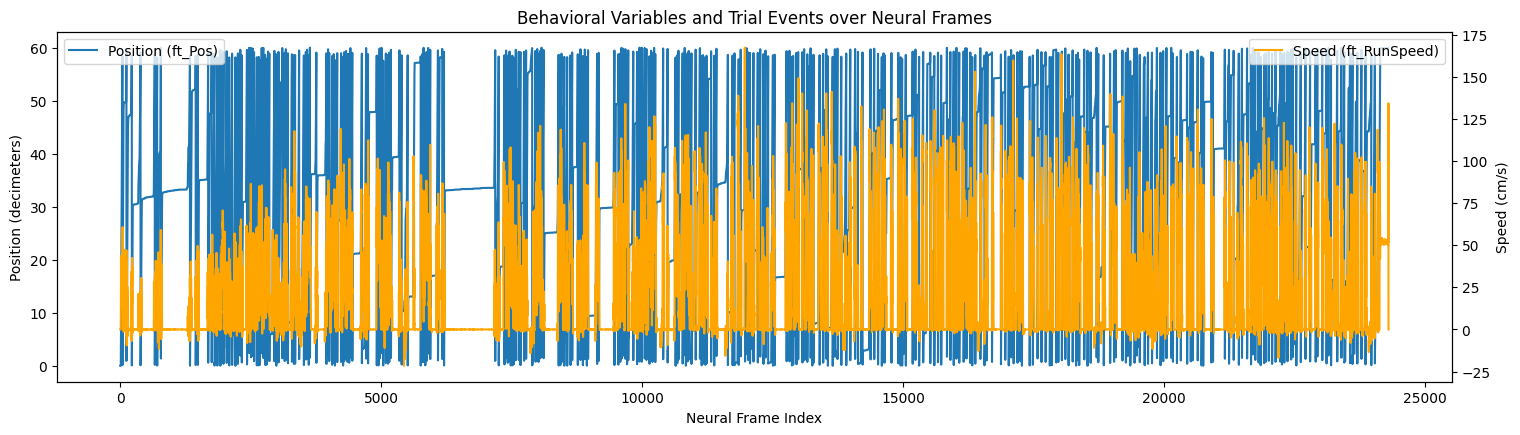


--- Analyzing SubjMTime Sampling ---
SubjMTime differences (first 10): [5.32367267e-07 2.77766958e-07 3.47266905e-07 3.24100256e-07
 3.70317139e-07 3.12458724e-07 2.54716724e-07 2.89292075e-07
 2.77766958e-07 2.89408490e-07]
Mean SubjMTime difference: 0.000000
Median SubjMTime difference: 0.000000
Min SubjMTime difference: 0.000000
Max SubjMTime difference: 0.000009


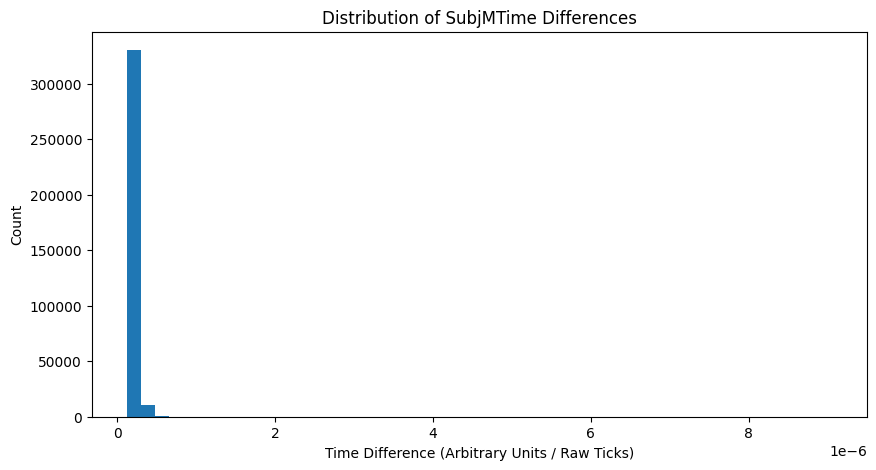

Inferred sampling rate for SubjMTime: 3757626.68 Hz

--- Analyzing Neural Frame Rate Using beh['ft'] ---
Neural frame time differences (first 10): [3.62715218e-06 3.64170410e-06 3.63984145e-06 3.65136657e-06
 3.64135485e-06 3.63879371e-06 3.62959690e-06 4.27127816e-06
 3.02132685e-06 3.69665213e-06]
Mean neural frame time difference: 0.000004
Median neural frame time difference: 0.000004
Min neural frame time difference: 0.000000
Max neural frame time difference: 0.000017


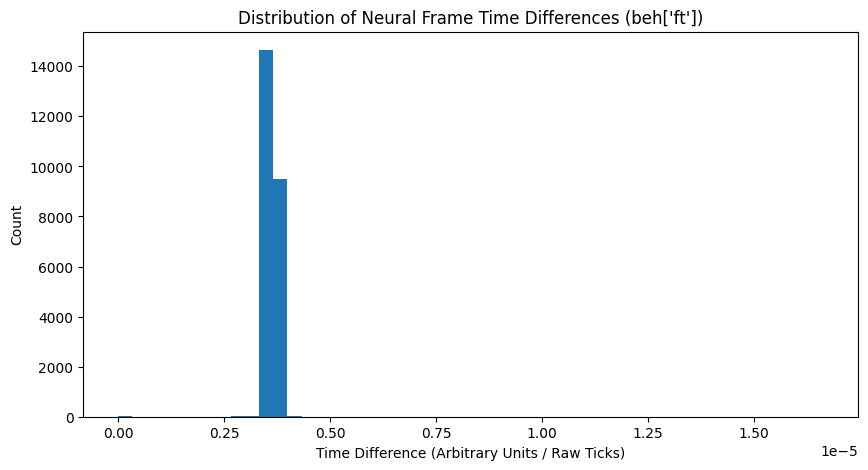

Inferred neural frame rate: 274561.61 Hz


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import interpolate

# Assuming 'root', 'sup_bef', 'beh' are already defined from previous cells
# If running this cell independently, ensure they are defined first.
# For example:
# root = r'/content/Zhong_et_al_2025'
# sup_bef = 'VR2_2021_03_20_1'
# beh = np.load(os.path.join(root, 'Beh_sup_train1_before_learning.npy'), allow_pickle=1).item()[sup_bef]
# example_raw_data = np.load(os.path.join(root, sup_bef + '_example_raw_spk.npy'))
# nfrs = example_raw_data.shape[1]
# stim1_idx = (beh['ft_WallID']==beh['UniqWalls'][beh['stim_id']==2][0]) & (beh['ft_Pos']<40)
# stim2_idx = (beh['ft_WallID']==beh['UniqWalls'][beh['stim_id']==0][0]) & (beh['ft_Pos']<40)
# gray_idx = ((beh['ft_WallID']==beh['UniqWalls'][beh['stim_id']==2][0]) | (beh['ft_WallID']==beh['UniqWalls'][beh['stim_id']==0][0])) & (beh['ft_Pos']>=40)
# ntrials = beh['ntrials']
# SoundPos = beh['SoundPos']
# interp_spk = np.empty((example_raw_data.shape[0], ntrials * 60)) # Placeholder, actual interpolation happens later

# --- Create df_frames for plotting behavioral variables aligned to neural frames ---
# This DataFrame will hold variables that have a direct correspondence to neural frames.
# 'ft' is the time stamp for each neural frame.
# 'ft_Pos' is position inside VR for each neural frame.
# 'ft_RunSpeed' is running speed for each neural frame.
df_frames = pd.DataFrame({
    'ft_Time': beh['ft'], # Time stamp for each neural frame (likely in very small units, e.g., microseconds or raw ticks)
    'ft_Pos': beh['ft_Pos'], # Position inside corridor (decimeters)
    'ft_RunSpeed': beh['ft_RunSpeed'], # Running speed (cm/s)
    'ft_WallID': beh['ft_WallID'] # Stimulus ID for each frame
})
print("df_frames created with columns:", df_frames.columns.tolist())
print("Shape of df_frames:", df_frames.shape)

# --- Create df_subj_move for analyzing SubjMTime sampling ---
# This DataFrame will hold the subject's movement data.
df_subj_move = pd.DataFrame({
    'SubjMTime': beh['SubjMove']['SubjMTime'], # Time stamps of running (likely in very small units, e.g., microseconds or raw ticks)
    'SubjMPos': beh['SubjMove']['SubjMPos'], # Position inside corridor
    'SubjM_pitch': beh['SubjMove']['SubjM_pitch'] # Pitch (forward) running speed
    # Add other 'SubjMove' variables if needed for future analysis
})
print("\ndf_subj_move created with columns:", df_subj_move.columns.tolist())
print("Shape of df_subj_move:", df_subj_move.shape)

# You can now re-run the plotting cells that use df_frames and df_subj_move.
# For the 'Plot ft_Pos and ft_RunSpeed on the same graph' cell,
# remember to update the x-axis label to reflect 'Neural Frame Index' or 'Time (s)'.
# For the 'Determining the Time Unit for SubjMTime and Sampling Rate of Optical Tracking' cell,
# the units should now be clearer.

# --- Updated plotting code for Behavioral Variables and Trial Events over Neural Frames ---
# This section assumes df_frames is already defined.
plt.figure(figsize=(18, 10))

# Plot ft_Pos and ft_RunSpeed on the same graph
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df_frames.index, df_frames['ft_Pos'], label='Position (ft_Pos)')
ax1_twin = ax1.twinx()
ax1_twin.plot(df_frames.index, df_frames['ft_RunSpeed'], color='orange', label='Speed (ft_RunSpeed)')

# Updated Y-axis labels with clarified units
ax1.set_ylabel('Position (decimeters)')
ax1_twin.set_ylabel('Speed (cm/s)')
ax1.set_title('Behavioral Variables and Trial Events over Neural Frames')
ax1.set_xlabel('Neural Frame Index') # Explicitly label x-axis
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
plt.show()

# --- Updated plotting code for SubjMTime Analysis ---
# This section assumes df_subj_move is already defined.
if 'df_subj_move' in locals() and not df_subj_move.empty:
    print("\n--- Analyzing SubjMTime Sampling ---")
    time_diffs_subj_m = np.diff(df_subj_move['SubjMTime'])

    print(f"SubjMTime differences (first 10): {time_diffs_subj_m[:10]}")
    print(f"Mean SubjMTime difference: {np.mean(time_diffs_subj_m):.6f}")
    print(f"Median SubjMTime difference: {np.median(time_diffs_subj_m):.6f}")
    print(f"Min SubjMTime difference: {np.min(time_diffs_subj_m):.6f}")
    print(f"Max SubjMTime difference: {np.max(time_diffs_subj_m):.6f}")

    plt.figure(figsize=(10, 5))
    plt.hist(time_diffs_subj_m, bins=50)
    plt.title('Distribution of SubjMTime Differences')
    # Updated X-axis label to be more general
    plt.xlabel('Time Difference (Arbitrary Units / Raw Ticks)')
    plt.ylabel('Count')
    plt.show()

    if np.median(time_diffs_subj_m) > 0:
        inferred_sampling_rate_subj_m = 1 / np.median(time_diffs_subj_m)
        print(f"Inferred sampling rate for SubjMTime: {inferred_sampling_rate_subj_m:.2f} Hz")
    else:
        print("Cannot infer sampling rate for SubjMTime: Median time difference is zero.")
else:
    print("df_subj_move not available or empty to analyze SubjMTime.")

# --- Updated plotting code for Neural Frame Rate Analysis ---
# This section assumes beh is already defined and 'ft' exists.
if 'beh' in locals() and 'ft' in beh:
    print("\n--- Analyzing Neural Frame Rate Using beh['ft'] ---")
    time_diffs_ft = np.diff(beh['ft'])

    print(f"Neural frame time differences (first 10): {time_diffs_ft[:10]}")
    print(f"Mean neural frame time difference: {np.mean(time_diffs_ft):.6f}")
    print(f"Median neural frame time difference: {np.median(time_diffs_ft):.6f}")
    print(f"Min neural frame time difference: {np.min(time_diffs_ft):.6f}")
    print(f"Max neural frame time difference: {np.max(time_diffs_ft):.6f}")

    plt.figure(figsize=(10, 5))
    plt.hist(time_diffs_ft, bins=50)
    plt.title("Distribution of Neural Frame Time Differences (beh['ft'])")
    # Updated X-axis label to be more general
    plt.xlabel('Time Difference (Arbitrary Units / Raw Ticks)')
    plt.ylabel('Count')
    plt.show()

    if np.median(time_diffs_ft) > 0:
        inferred_neural_frame_rate = 1 / np.median(time_diffs_ft)
        print(f"Inferred neural frame rate: {inferred_neural_frame_rate:.2f} Hz")
    else:
        print("Cannot infer neural frame rate: Median time difference is zero.")
else:
    print("beh or beh['ft'] not available to analyze neural frame rate.")


In [ ]:
import pandas as pd
import numpy as np
import os
!pip install xlsxwriter

frame_level_keys = [
    'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum',
    'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc',
    'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'RunFr', 'BefCueFr', 'AftCueFr'
]

frame_data = {key: beh[key] for key in frame_level_keys}

trial_keys_to_join = [
    'Trial_start_time', 'Trial_end_time', 'SoundPos', 'SoundTime',
    'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType',
    'WallIsProbe', 'WallName', 'TrialStim', 'RewardFr', 'StartFr',
    'GrayFr', 'EndFr', 'SoundDelayFr', 'SoundDelPos'
]

run_pos_df = pd.DataFrame(beh['run_pos'])
run_pos_df.columns = [f'run_pos_{i}' for i in range(run_pos_df.shape[1])]
trial_level_df_for_merge = pd.DataFrame({k: beh[k] for k in trial_keys_to_join})
trial_level_df_for_merge['trInd'] = beh['trInd']
trial_level_df_for_merge = pd.concat([trial_level_df_for_merge, run_pos_df], axis=1)


df_frames = pd.DataFrame(frame_data)
df_frames = df_frames.merge(trial_level_df_for_merge,
                            left_on='ft_trInd',
                            right_on='trInd',
                            how='left',
                            suffixes=('_frame', '_trial'))

if 'trInd_trial' in df_frames.columns and 'ft_trInd' in df_frames.columns:
    if df_frames['trInd_trial'].equals(df_frames['ft_trInd']):
        df_frames = df_frames.drop(columns=['trInd_trial'])

print("\n--- Frame-level DataFrame (df_frames) ---")
print(df_frames.head())
print(f"Shape of Frame-level DataFrame: {df_frames.shape}")
print(f"Columns in Frame-level DataFrame: {df_frames.columns.tolist()}")

lick_level_keys = [
    'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'LickFr'
]
df_licks = pd.DataFrame({key: beh[key] for key in lick_level_keys})

df_licks = df_licks.merge(trial_level_df_for_merge,
                           left_on='LickTrind',
                           right_on='trInd',
                           how='left',
                           suffixes=('_lick', '_trial'))

if 'trInd_trial' in df_licks.columns and 'LickTrind' in df_licks.columns:
    if df_licks['trInd_trial'].equals(df_licks['LickTrind']):
        df_licks = df_licks.drop(columns=['trInd_trial'])


print("\n--- Lick-event DataFrame (df_licks) ---")
print(df_licks.head())
print(f"Shape of Lick-event DataFrame: {df_licks.shape}")
print(f"Columns in Lick-event DataFrame: {df_licks.columns.tolist()}")

vr_pos_keys = [
    'VRposTime', 'VRpos', 'VRposCum'
]
df_vr_pos = pd.DataFrame({key: beh[key] for key in vr_pos_keys})

print("\n--- VR Position DataFrame (df_vr_pos) ---")
print(df_vr_pos.head())
print(f"Shape of VR Position DataFrame: {df_vr_pos.shape}")

scalar_data = {
    key: beh[key] for key in ['ntrials', 'Corridor_Length', 'Gray_Space_length',
                               'Texture_Length', 'Reward_Mode', 'Reward_Delay_ms']
}
print("\n--- Scalar Data ---")
for key, value in scalar_data.items():
    print(f"  {key}: {value}")

"""output_excel_file = 'processed_behavioral_data.xlsx'

with pd.ExcelWriter(output_excel_file, engine='xlsxwriter') as writer:
    df_frames.to_excel(writer, sheet_name='Frame_Data', index=False)
    df_licks.to_excel(writer, sheet_name='Lick_Data', index=False)
    df_vr_pos.to_excel(writer, sheet_name='VR_Position_Data', index=False)

    scalar_df = pd.DataFrame.from_dict(scalar_data, orient='index', columns=['Value'])
    scalar_df.to_excel(writer, sheet_name='Scalar_Data')

print(f"\nAll DataFrames saved to '{output_excel_file}' successfully.")"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 4.0 MB/s eta 0:00:00

--- Frame-level DataFrame (df_frames) ---
              ft  ft_trInd  ft_trInd_odd  ft_trInd_even  ft_PosCum  ft_Pos  \
0  738235.709664       NaN         False          False        0.0     0.0   
1  738235.709667       NaN         False          False        0.0     0.0   
2  738235.709671       NaN         False          False        0.0     0.0   
3  738235.709675       NaN         False          False        0.0     0.0   
4  738235.709678       NaN         False          False        0.0     0.0   

   ft_move  ft_isMoving  ft_GraySpc  ft_CorrSpc  ... run_pos_50  run_pos_51  \
0      0.0        False       False        True  ...        NaN         NaN   
1      0.0        False       False        True  ...        NaN         NaN   
2      0.0        False       False        True  ...        NaN         NaN   
3      0.0        False       False        True  ...        NaN         NaN   
4      0.0   

'output_excel_file = \'processed_behavioral_data.xlsx\'\n\nwith pd.ExcelWriter(output_excel_file, engine=\'xlsxwriter\') as writer:\n    df_frames.to_excel(writer, sheet_name=\'Frame_Data\', index=False)\n    df_licks.to_excel(writer, sheet_name=\'Lick_Data\', index=False)\n    df_vr_pos.to_excel(writer, sheet_name=\'VR_Position_Data\', index=False)\n\n    scalar_df = pd.DataFrame.from_dict(scalar_data, orient=\'index\', columns=[\'Value\'])\n    scalar_df.to_excel(writer, sheet_name=\'Scalar_Data\')\n\nprint(f"\nAll DataFrames saved to \'{output_excel_file}\' successfully.")'

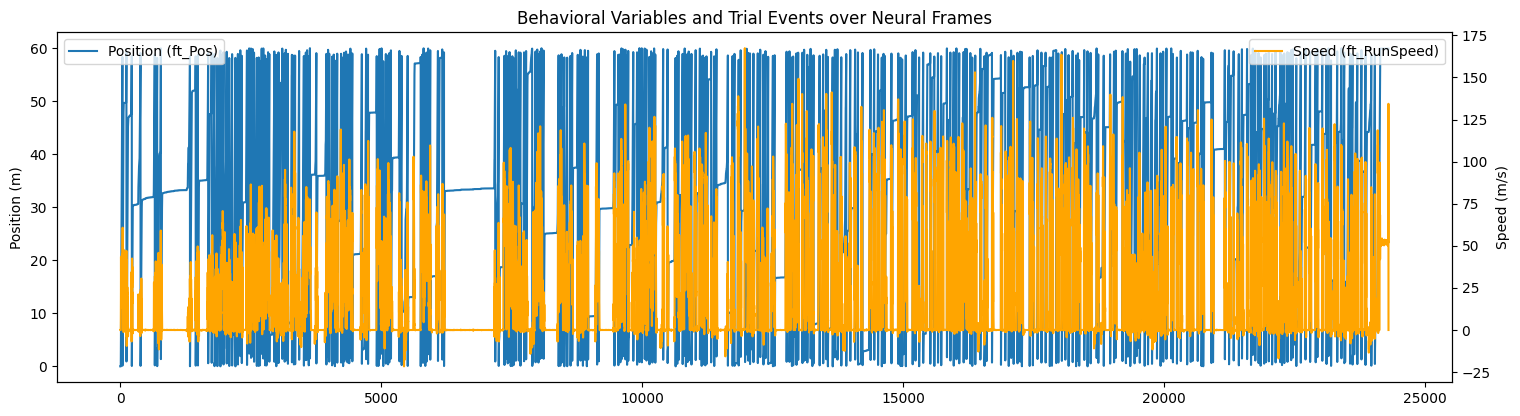

In [ ]:
plt.figure(figsize=(18, 10))

# Plot ft_Pos and ft_RunSpeed on the same graph
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df_frames.index, df_frames['ft_Pos'], label='Position (ft_Pos)')
ax1_twin = ax1.twinx()
ax1_twin.plot(df_frames.index, df_frames['ft_RunSpeed'], color='orange', label='Speed (ft_RunSpeed)')
ax1.set_ylabel('Position (m)')
ax1_twin.set_ylabel('Speed (m/s)') # Assuming meters/sec, adjust if different
ax1.set_title('Behavioral Variables and Trial Events over Neural Frames')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

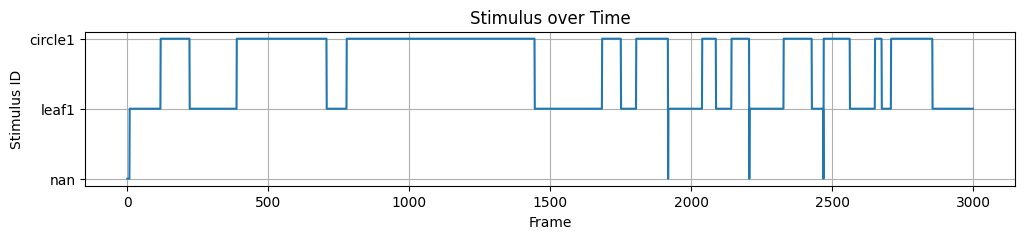

In [ ]:
plt.figure(figsize=(12, 2))
plt.plot(stim_fr[:3000], label='Stimulus ID')
plt.title("Stimulus over Time")
plt.xlabel("Frame")
plt.ylabel("Stimulus ID")
plt.grid(True)
plt.show()


Overlay Mouse Behavior (Speed & Position)

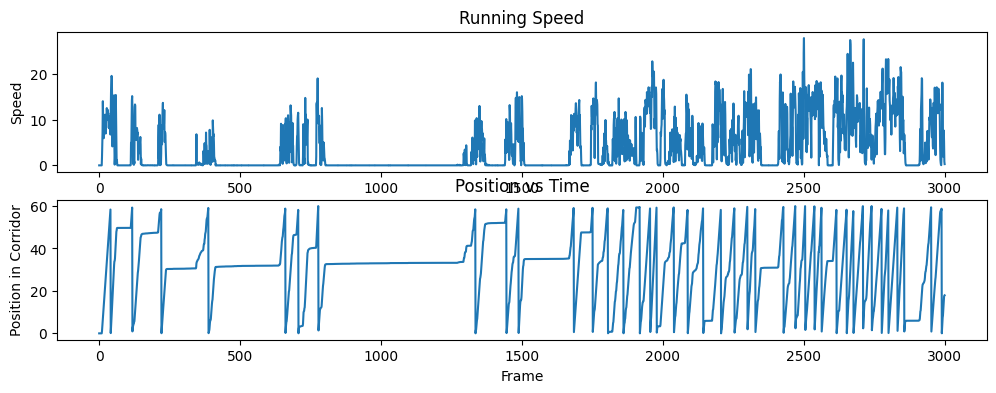

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(2, 1, 1)
plt.plot(beh['RunFr'][:3000])
plt.title("Running Speed")
plt.ylabel("Speed")

plt.subplot(2, 1, 2)
plt.plot(beh['ft_Pos'][:3000], label='Position')
plt.ylabel("Position in Corridor")
plt.xlabel("Frame")
plt.title("Position vs Time")
plt.show()


Plot Neural Activity with Behavioral Context

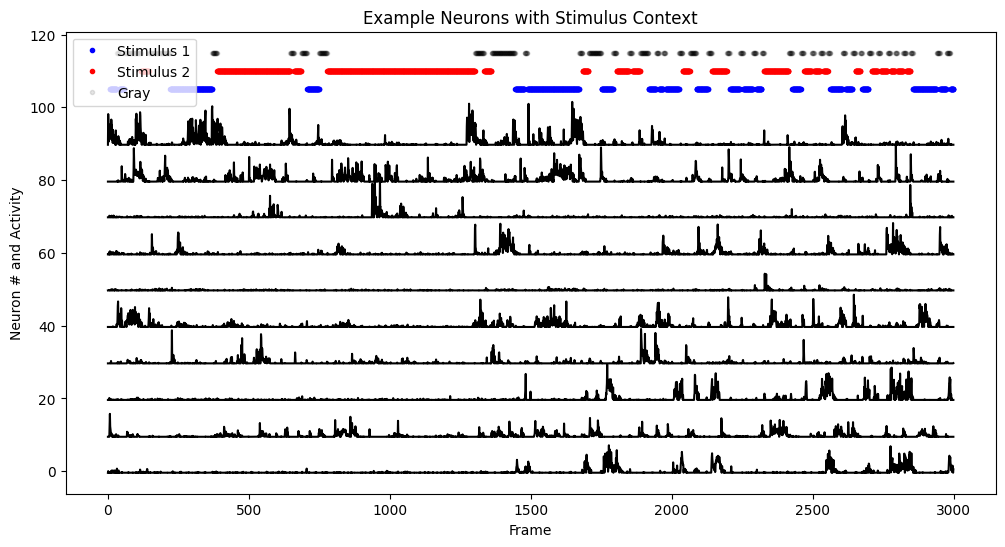

In [ ]:
nneu = 10
nfr = 3000

plt.figure(figsize=(12, 6))
for i in range(nneu):
    plt.plot(example_raw_data[i, :nfr] + i*10, color='black')

plt.plot(np.where(stim1_idx[:nfr])[0], np.ones(stim1_idx[:nfr].sum()) * (nneu*10 + 5), 'b.', label='Stimulus 1')
plt.plot(np.where(stim2_idx[:nfr])[0], np.ones(stim2_idx[:nfr].sum()) * (nneu*10 + 10), 'r.', label='Stimulus 2')
plt.plot(np.where(gray_idx[:nfr])[0], np.ones(gray_idx[:nfr].sum()) * (nneu*10 + 15), 'k.', alpha=0.1, label='Gray')

plt.legend()
plt.title("Example Neurons with Stimulus Context")
plt.xlabel("Frame")
plt.ylabel("Neuron # and Activity")
plt.show()


Using firing rate threshold: 0.5 for raster plots.
Displaying 1000 neurons over 24000 frames.


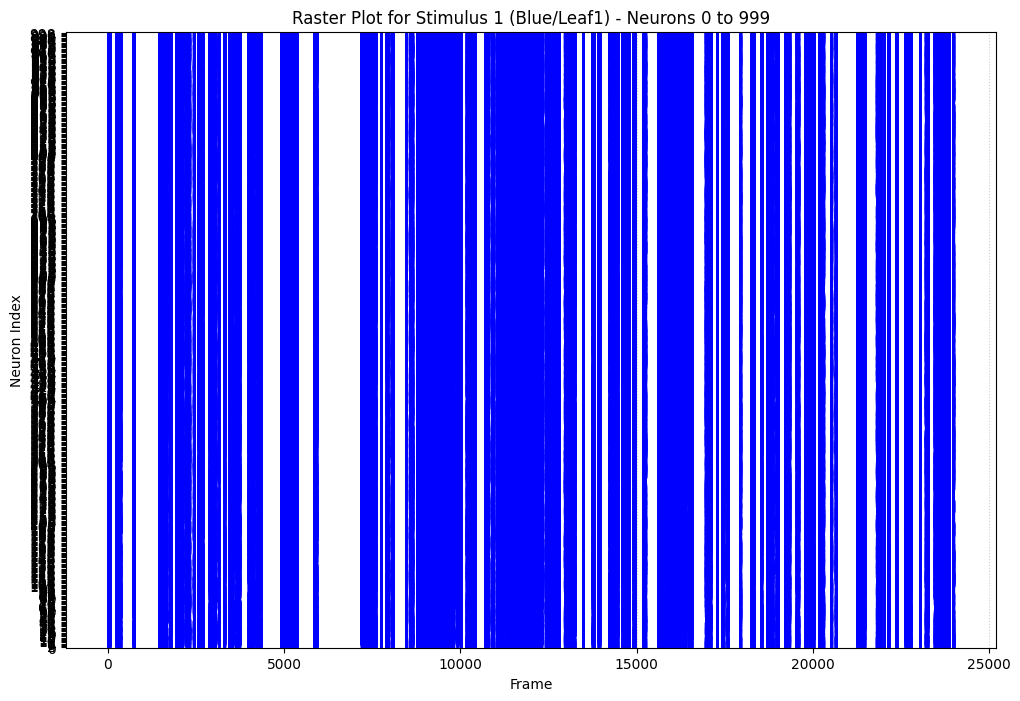

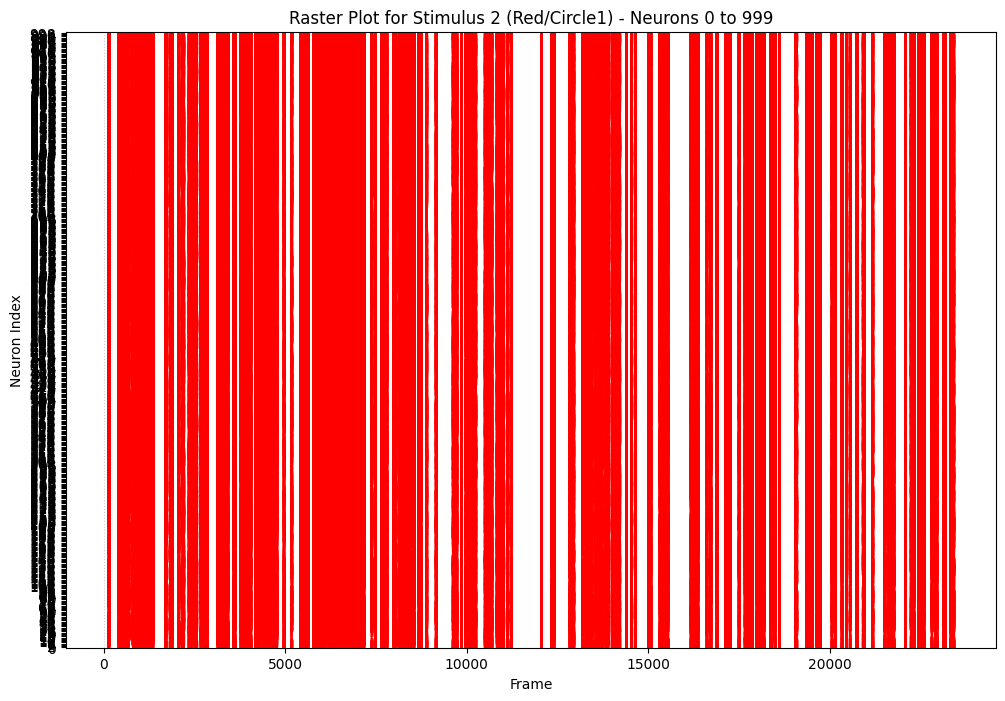


Note: The 'firing_rate_threshold' is critical for these plots.
Adjust it to best represent 'active' states in your data.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- ASSUMPTION: These variables are already defined and loaded from previous steps ---
# example_raw_data (shape: [num_neurons, num_frames]) - Your raw neural data
# stim1_idx (shape: [num_frames,]) - Boolean mask for Stimulus 1 (Leaf1, blue)
# stim2_idx (shape: [num_frames,]) - Boolean mask for Stimulus 2 (Circle1, red)
# ------------------------------------------------------------------------------------

# Define the number of neurons and frames to visualize in the raster plots
nneu_to_plot = 1000 # You can adjust this to plot more or fewer neurons
nfr_to_plot = 24000 # Max frames to consider for plotting, similar to your original plot

# --- IMPORTANT: Define a firing rate threshold for your raster plot ---
# This threshold determines what counts as an "active" event or "spike"
# You will need to adjust this based on your data's typical firing rate values.
# Look at your `Neuron 0 Activity vs Stimuli` plot to pick a reasonable value.
firing_rate_threshold = 0.5 # Example threshold. Adjust this!

print(f"Using firing rate threshold: {firing_rate_threshold} for raster plots.")
print(f"Displaying {nneu_to_plot} neurons over {nfr_to_plot} frames.")


# Ensure the masks are trimmed to the plotting frames if necessary
stim1_mask_plot = stim1_idx[:nfr_to_plot]
stim2_mask_plot = stim2_idx[:nfr_to_plot]


# --- Raster Plot for Stimulus 1 (Blue) ---
plt.figure(figsize=(12, 8))
for i in range(nneu_to_plot):
    # Get the firing rates for the current neuron within the plotting range
    neuron_activity = example_raw_data[i, :nfr_to_plot]

    # Select activity only during Stimulus 1
    stim1_activity = neuron_activity[stim1_mask_plot]
    stim1_frames = np.where(stim1_mask_plot)[0]

    # Find frames where the neuron is active during Stimulus 1
    active_stim1_frames = stim1_frames[stim1_activity > firing_rate_threshold]

    # Plot a marker for each active frame
    # We plot it at the original frame index for the time axis, and 'i' for neuron index
    plt.plot(active_stim1_frames, np.ones_like(active_stim1_frames) * i,
             '|', color='blue', markersize=8, markeredgewidth=1) # '|' creates vertical lines

plt.xlabel("Frame")
plt.ylabel("Neuron Index")
plt.title(f"Raster Plot for Stimulus 1 (Blue/Leaf1) - Neurons 0 to {nneu_to_plot-1}")
plt.yticks(np.arange(0, nneu_to_plot, 2)) # Adjust y-ticks for clarity
plt.ylim(-0.5, nneu_to_plot - 0.5) # Ensure neurons are centered on their index
plt.grid(axis='x', linestyle=':', alpha=0.6) # Grid for time reference
plt.show()


# --- Raster Plot for Stimulus 2 (Red) ---
plt.figure(figsize=(12, 8))
for i in range(nneu_to_plot):
    # Get the firing rates for the current neuron within the plotting range
    neuron_activity = example_raw_data[i, :nfr_to_plot]

    # Select activity only during Stimulus 2
    stim2_activity = neuron_activity[stim2_mask_plot]
    stim2_frames = np.where(stim2_mask_plot)[0]

    # Find frames where the neuron is active during Stimulus 2
    active_stim2_frames = stim2_frames[stim2_activity > firing_rate_threshold]

    # Plot a marker for each active frame
    plt.plot(active_stim2_frames, np.ones_like(active_stim2_frames) * i,
             '|', color='red', markersize=8, markeredgewidth=1) # '|' creates vertical lines

plt.xlabel("Frame")
plt.ylabel("Neuron Index")
plt.title(f"Raster Plot for Stimulus 2 (Red/Circle1) - Neurons 0 to {nneu_to_plot-1}")
plt.yticks(np.arange(0, nneu_to_plot, 2)) # Adjust y-ticks for clarity
plt.ylim(-0.5, nneu_to_plot - 0.5)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

print("\nNote: The 'firing_rate_threshold' is critical for these plots.")
print("Adjust it to best represent 'active' states in your data.")

Example Neuron’s Response for Each Stimulus

plot one neuron and its activity aligned to different stimulus types.

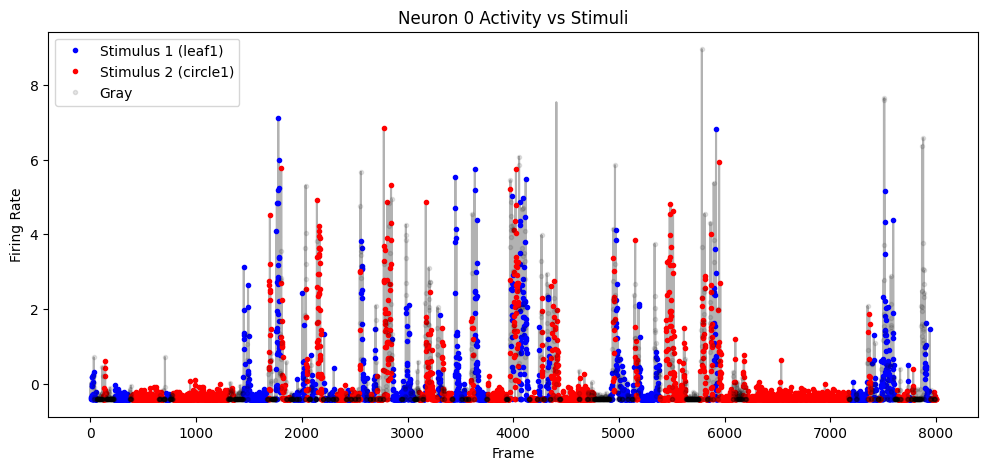

In [ ]:
neuron_idx = 0  # choose one neuron
nfr = 8000      # number of frames to show

plt.figure(figsize=(12, 5))
plt.plot(example_raw_data[neuron_idx, :nfr], color='gray', alpha=0.6)

plt.plot(np.where(stim1_idx[:nfr])[0],
         example_raw_data[neuron_idx, :nfr][stim1_idx[:nfr]],
         'b.', label='Stimulus 1 (leaf1)')

plt.plot(np.where(stim2_idx[:nfr])[0],
         example_raw_data[neuron_idx, :nfr][stim2_idx[:nfr]],
         'r.', label='Stimulus 2 (circle1)')

plt.plot(np.where(gray_idx[:nfr])[0],
         example_raw_data[neuron_idx, :nfr][gray_idx[:nfr]],
         'k.', alpha=0.1, label='Gray')
plt.legend()
plt.title(f"Neuron {neuron_idx} Activity vs Stimuli")
plt.xlabel("Frame")
plt.ylabel("Firing Rate")
plt.show()


Average Response Over Trials for Each Stimulus

plot mean neural response across all trials per stimulus.

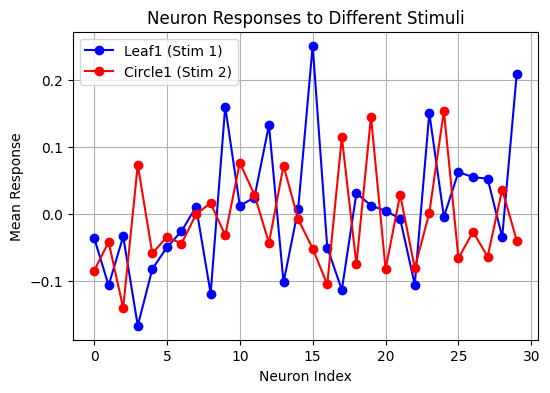

In [ ]:
min_len = min(example_raw_data.shape[1], stim1_idx.shape[0])

stim1_mask = stim1_idx[:min_len]
stim2_mask = stim2_idx[:min_len]

stim1_resp = example_raw_data[:, :min_len][:, stim1_mask]
stim2_resp = example_raw_data[:, :min_len][:, stim2_mask]

mean_resp1 = np.mean(stim1_resp, axis=1)
mean_resp2 = np.mean(stim2_resp, axis=1)

plt.figure(figsize=(6, 4))
plt.plot(mean_resp1[:30], 'bo-', label='Leaf1 (Stim 1)')
plt.plot(mean_resp2[:30], 'ro-', label='Circle1 (Stim 2)')
plt.xlabel("Neuron Index")
plt.ylabel("Mean Response")
plt.title("Neuron Responses to Different Stimuli")
plt.legend()
plt.grid(True)
plt.show()


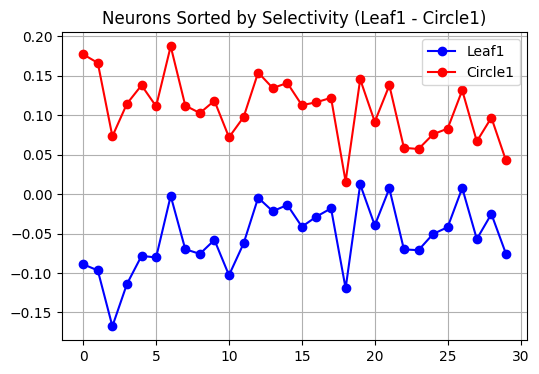

In [ ]:
selectivity = mean_resp1 - mean_resp2
sorted_idx = np.argsort(selectivity)

plt.figure(figsize=(6, 4))
plt.plot(mean_resp1[sorted_idx[:30]], 'bo-', label='Leaf1')
plt.plot(mean_resp2[sorted_idx[:30]], 'ro-', label='Circle1')
plt.title("Neurons Sorted by Selectivity (Leaf1 - Circle1)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
std_resp1 = np.std(stim1_resp, axis=1)
std_resp2 = np.std(stim2_resp, axis=1)
dprime = (mean_resp1 - mean_resp2) / np.sqrt(0.5 * (std_resp1**2 + std_resp2**2))


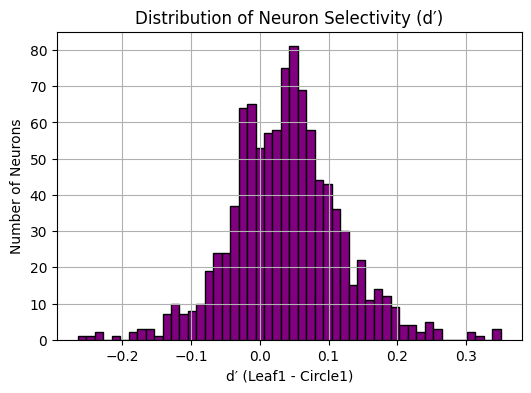

In [ ]:
# Histogram of d′
plt.figure(figsize=(6, 4))
plt.hist(dprime, bins=50, color='purple', edgecolor='black')
plt.title("Distribution of Neuron Selectivity (d′)")
plt.xlabel("d′ (Leaf1 - Circle1)")
plt.ylabel("Number of Neurons")
plt.grid(True)
plt.show()


In [ ]:
n_total = len(dprime)
n_selective_leaf = np.sum(dprime > 0)
n_selective_circle = np.sum(dprime < 0)
n_nonselective = n_total - n_selective_leaf - n_selective_circle

print(f"Total neurons: {n_total}")
print(f"Leaf1-selective (d′ > 1): {n_selective_leaf}")
print(f"Circle1-selective (d′ < -1): {n_selective_circle}")
print(f"Non-selective: {n_nonselective}")

Total neurons: 1000
Leaf1-selective (d′ > 1): 679
Circle1-selective (d′ < -1): 321
Non-selective: 0


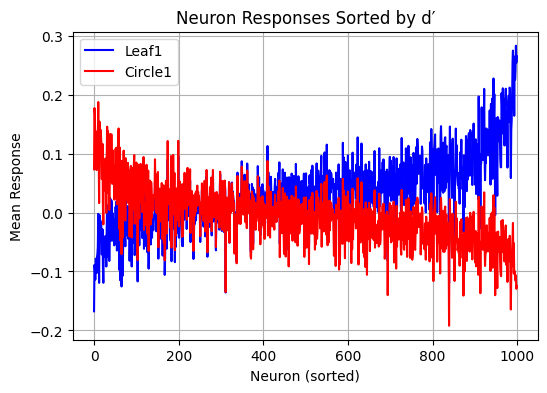

In [ ]:
sorted_idx = np.argsort(dprime)

plt.figure(figsize=(6, 4))
plt.plot(mean_resp1[sorted_idx], 'b-', label='Leaf1')
plt.plot(mean_resp2[sorted_idx], 'r-', label='Circle1')
plt.title("Neuron Responses Sorted by d′")
plt.xlabel("Neuron (sorted)")
plt.ylabel("Mean Response")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# beh = beh_aft  or beh = beh_bef
beh = beh_aft  # or beh_bef, or unsup session

stim_ids = beh['stim_id']         # stimulus ID per trial (0–6)

unique_stim_ids_in_data = np.unique(stim_ids)

stim_id_to_name_map = {}

all_unique_wall_names = beh['UniqWalls']

print(f"Type of beh['UniqWalls']: {type(beh['UniqWalls'])}")
print(f"Content of beh['UniqWalls']: {beh['UniqWalls']}")
print(f"Length of beh['UniqWalls']: {len(beh['UniqWalls'])}")
print(f"Unique stim_ids found in data: {np.unique(stim_ids)}")
print(f"Max stim_id found: {np.max(stim_ids)}")

stim_id_to_name_map = {
    0: 'Circle1',  # Assuming stim_id 0 maps to 'Circle1'
    1: 'WallB',    # Assuming stim_id 1 maps to 'WallB' (placeholder)
    2: 'Leaf1',    # Assuming stim_id 2 maps to 'Leaf1'
}

stim_id_to_name_map = {}
stim_id_to_name_mapping = {
    0: 'Circle1',  # Example: ID 0 maps to 'Circle1'
    1: 'WallA',    # Example: ID 1 maps to 'WallA' (if it exists)
    2: 'Leaf1',    # Example: ID 2 maps to 'Leaf1'
}

stim_id_to_name_lookup = {
    0: 'Circle1',
    1: 'Corridor_A', # Placeholder, replace with actual name if ID 1 exists
    2: 'Leaf1',
    3: 'Corridor_B', # Placeholder
    4: 'Corridor_C', # Placeholder
    5: 'Corridor_D', # Placeholder
    6: 'Corridor_E'  # Placeholder
}


# Get trial-wise info
stim_ids = beh['stim_id']         # stimulus ID per trial (0–6)
rewarded = beh['isRew']           # boolean array: True if trial was rewarded

# Count correct and total trials per stimulus
correct_counts = defaultdict(int)
total_counts = defaultdict(int)

for stim_id, is_correct in zip(stim_ids, rewarded):
    # Use the lookup dictionary here instead of direct indexing `stim_names[stim_id]`
    try:
        stim_name = stim_id_to_name_lookup[stim_id]
    except KeyError:
        print(f"Warning: Stimulus ID {stim_id} found in data but not in 'stim_id_to_name_lookup'. Skipping this trial.")
        continue # Skip trials with unmapped stimulus IDs

    total_counts[stim_name] += 1
    if is_correct:
        correct_counts[stim_name] += 1

# Compute accuracy
# Ensure `wall_names` are taken from the keys that actually received counts
wall_names = list(total_counts.keys())
# Sort the wall names for consistent plotting order, if desired
wall_names.sort() # Optional: Sort alphabetically or by some defined order

accuracy = [correct_counts[w] / total_counts[w] for w in wall_names]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(wall_names, accuracy, color='royalblue')
plt.ylim(0, 1.05)
plt.ylabel("Accuracy (Rewarded Trials / Total Trials)")
plt.xlabel("Stimulus (Corridor)")
plt.title("Mouse Accuracy per Stimulus")
plt.grid(True, axis='y')

# Annotate bars with % accuracy
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{acc*100:.1f}%", ha='center', fontsize=10)

plt.show()

NameError: name 'beh_aft' is not defined

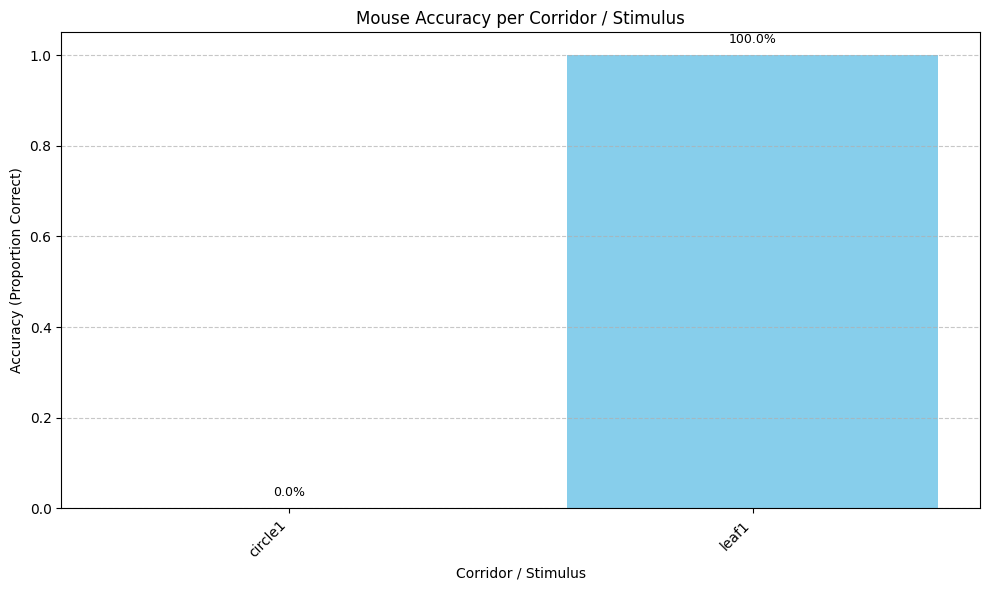


--- Accuracy Summary ---
circle1: 0.0% Accurate (0 / 170 trials)
leaf1: 100.0% Accurate (178 / 178 trials)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# --- ASSUMPTION: 'beh' variable is already loaded and available ---
# For example, from previous steps:
# beh = np.load(os.path.join(root, 'Beh_sup_train1_after_learning.npy'), allow_pickle=True).item()[sup_aft]
# Or beh = beh_bef
# -----------------------------------------------------------------

# Extract relevant information from beh
wall_names_per_trial = beh['WallName']
is_rewarded_per_trial = beh['isRew'] # boolean: True if trial was rewarded (correct)

# --- Count correct and total trials per stimulus name ---
total_counts = defaultdict(int)
correct_counts = defaultdict(int)

# Ensure data arrays have matching lengths
if len(wall_names_per_trial) != len(is_rewarded_per_trial):
    print("Warning: Length of 'WallName' and 'isRew' arrays do not match. Trimming to shortest length.")
    min_len = min(len(wall_names_per_trial), len(is_rewarded_per_trial))
    wall_names_per_trial = wall_names_per_trial[:min_len]
    is_rewarded_per_trial = is_rewarded_per_trial[:min_len]

for wall_name, is_correct in zip(wall_names_per_trial, is_rewarded_per_trial):
    # Ensure wall_name is a string for dictionary keys (handle NumPy object arrays if present)
    if isinstance(wall_name, (np.ndarray, np.void)) and wall_name.size == 1:
        wall_name = str(wall_name.item())
    else:
        wall_name = str(wall_name) # Convert to string to be safe for non-numpy cases too

    total_counts[wall_name] += 1
    if is_correct: # `is_correct` is already a boolean (True for rewarded)
        correct_counts[wall_name] += 1

# --- Prepare data for plotting ---
# Get all unique wall names that appeared in the trials and sort them for consistent plotting
all_unique_corridor_names = sorted(list(total_counts.keys()))

accuracy_per_corridor = []
for name in all_unique_corridor_names:
    total = total_counts[name]
    if total > 0:
        accuracy = correct_counts[name] / total
        accuracy_per_corridor.append(accuracy)
    else:
        accuracy_per_corridor.append(0) # If a corridor had 0 trials, its accuracy is 0

# --- Plotting: Simple Bar Chart for Accuracy ---
plt.figure(figsize=(10, 6))

bars = plt.bar(all_unique_corridor_names, accuracy_per_corridor, color='skyblue')

# Add labels and title
plt.ylim(0, 1.05) # Accuracy from 0 to 1
plt.ylabel("Accuracy (Proportion Correct)")
plt.xlabel("Corridor / Stimulus")
plt.title("Mouse Accuracy per Corridor / Stimulus")
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# --- Optional: Annotate bars with percentage accuracy ---
for bar, acc in zip(bars, accuracy_per_corridor):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, # Position slightly above the bar
             f"{acc*100:.1f}%", ha='center', va='bottom', fontsize=9, color='black')

plt.show()

print("\n--- Accuracy Summary ---")
for name, acc in zip(all_unique_corridor_names, accuracy_per_corridor):
    print(f"{name}: {acc*100:.1f}% Accurate ({correct_counts[name]} / {total_counts[name]} trials)")

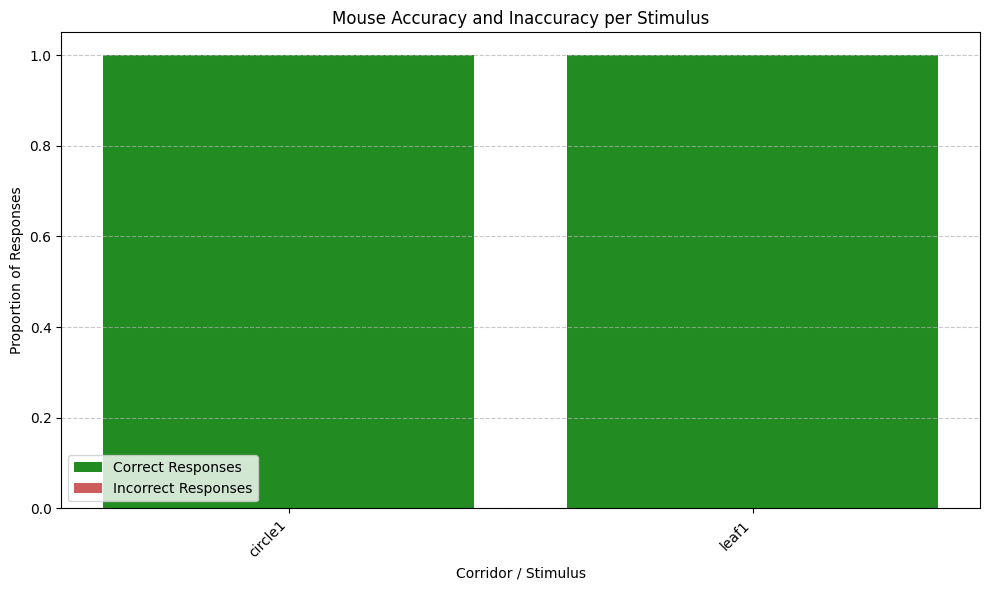

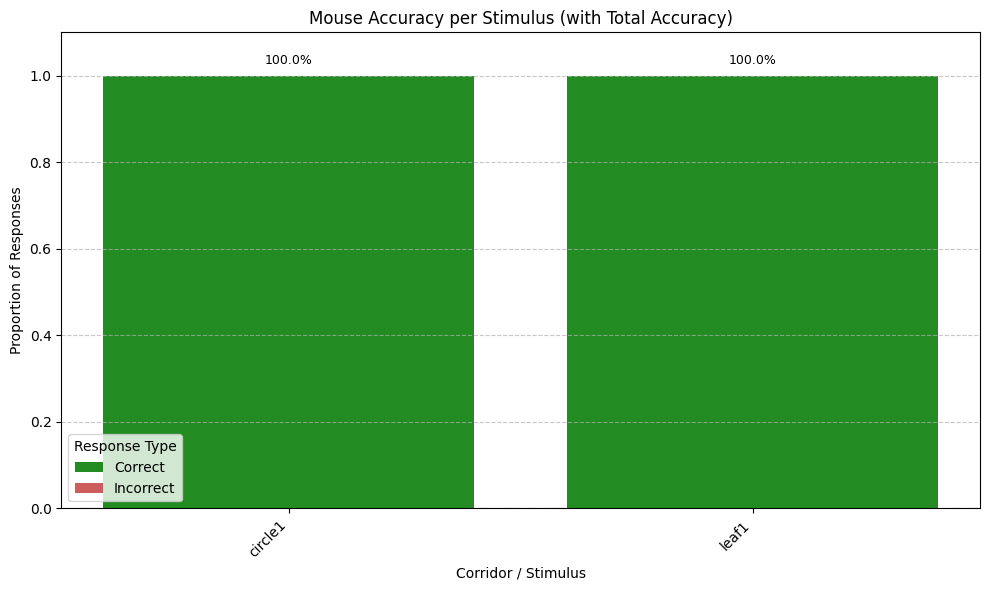

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# beh = beh_aft  # Or beh_bef, depending on which session you're analyzing
# Assuming 'beh' is already loaded from your previous steps, e.g.:
# beh = np.load(os.path.join(root, 'Beh_sup_train1_after_learning.npy'), allow_pickle=True).item()[sup_aft]

# --- Extract relevant information from beh ---
# The previous `stim_ids` and `rewarded` are correct:
stim_ids_per_trial = beh['stim_id'] # ID of stimuli for each trial
is_rewarded_per_trial = beh['isRew'] # boolean: True if trial was rewarded (correct)

# The most crucial piece: The mapping from stim_id (numeric) to stimulus name (string).
# Based on your provided info:
# beh['stim_id']: ID of stimuli; 0:circle1, 1:circle2, 2:leaf1, 3:leaf2 4:leaf3, 5:leaf1_swap1, 6:leaf1_swap2
# This is a direct, explicit mapping! We can create a dictionary from this.
stim_id_to_name_map = {
    0: 'circle1',
    1: 'circle2',
    2: 'leaf1',
    3: 'leaf2',
    4: 'leaf3',
    5: 'leaf1_swap1',
    6: 'leaf1_swap2'
}

# --- Count correct, incorrect, and total trials per stimulus ---
total_counts = defaultdict(int)
correct_counts = defaultdict(int)
incorrect_counts = defaultdict(int) # We'll need this for incorrect responses

# Iterate through each trial's stimulus ID and reward status
for trial_stim_id, trial_is_rewarded in zip(stim_ids_per_trial, is_rewarded_per_trial):
    # Get the stimulus name using our explicit map
    try:
        stim_name = stim_id_to_name_map[trial_stim_id]
    except KeyError:
        print(f"Warning: Stimulus ID {trial_stim_id} found in trial data but not in 'stim_id_to_name_map'. Skipping this trial.")
        continue

    total_counts[stim_name] += 1
    if trial_is_rewarded:
        correct_counts[stim_name] += 1
    else:
        incorrect_counts[stim_name] += 1

# --- Prepare data for plotting ---
# Get all stimulus names that appeared in the trials and sort them for consistent plotting
all_wall_names_present = sorted(list(total_counts.keys()))

# Calculate proportions for plotting
proportions_correct = []
proportions_incorrect = []
for name in all_wall_names_present:
    total = total_counts[name]
    if total > 0:
        proportions_correct.append(correct_counts[name] / total)
        proportions_incorrect.append(incorrect_counts[name] / total)
    else: # Should not happen if `name` is in `all_wall_names_present` derived from `total_counts.keys()`
        proportions_correct.append(0)
        proportions_incorrect.append(0)

# Convert to numpy arrays for easier handling with plotting functions
proportions_correct = np.array(proportions_correct)
proportions_incorrect = np.array(proportions_incorrect)

# --- Plotting: Stacked Bar Chart ---
plt.figure(figsize=(10, 6))

# Plot the 'correct' bars
bars_correct = plt.bar(all_wall_names_present, proportions_correct, color='forestgreen', label='Correct Responses')

# Plot the 'incorrect' bars, stacked on top of the 'correct' bars
bars_incorrect = plt.bar(all_wall_names_present, proportions_incorrect,
                         bottom=proportions_correct, # This is key for stacking
                         color='indianred', label='Incorrect Responses')

plt.ylim(0, 1.05) # Proportion from 0 to 1
plt.ylabel("Proportion of Responses")
plt.xlabel("Corridor / Stimulus")
plt.title("Mouse Accuracy and Inaccuracy per Stimulus")
plt.xticks(rotation=45, ha='right') # Rotate labels for readability if names are long
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# --- Optional: Annotate bars with percentages (total accuracy) ---
# You can also add the total accuracy percentage on top of each stacked bar
plt.figure(figsize=(10, 6))

bars_correct = plt.bar(all_wall_names_present, proportions_correct, color='forestgreen', label='Correct')
bars_incorrect = plt.bar(all_wall_names_present, proportions_incorrect,
                         bottom=proportions_correct,
                         color='indianred', label='Incorrect')

# Annotate each bar with the total accuracy
for i, name in enumerate(all_wall_names_present):
    total_accuracy = proportions_correct[i]
    plt.text(bars_correct[i].get_x() + bars_correct[i].get_width() / 2,
             bars_correct[i].get_height() + 0.02, # Position slightly above the correct bar
             f"{total_accuracy*100:.1f}%", ha='center', va='bottom', fontsize=9, color='black')

plt.ylim(0, 1.1) # Extend y-limit slightly to make space for annotations
plt.ylabel("Proportion of Responses")
plt.xlabel("Corridor / Stimulus")
plt.title("Mouse Accuracy per Stimulus (with Total Accuracy)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Response Type")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize data
stim_ids = beh['stim_id']  # Identifiers for stimuli (e.g., leaf1, circle1)
wall_names = beh['WallName']  # Names of the corridors
lick_times = beh['LickTime']  # Times of licking
correct_responses = []  # To store if the response is correct or not (1 for correct, 0 for incorrect)

# Loop through trials and calculate accuracy for each stimulus
#for i in range(len(stim_ids)):
    # Check if the response was correct (assuming 1 m

**From now on we working on Compare Before vs. After Learning**

In [ ]:
import os
import requests
import json

# Define destination folder
root = '/content/Zhong_et_al_2025'
os.makedirs(root, exist_ok=True)

# Figshare article and file ID
article_id = 28811129
target_file_id = 54866333
target_file_name = 'VR2_2021_04_06_1_example_raw_spk.npy'

# Check if file already exists
destination = os.path.join(root, target_file_name)
if not os.path.exists(destination):
    print(f"Downloading {target_file_name} from Figshare...")

    # Get metadata
    BASE_URL = 'https://api.figshare.com/v2'
    r = requests.get(f'{BASE_URL}/articles/{article_id}')
    file_metadata = json.loads(r.text)

    # Find and download the correct file
    for file in file_metadata['files']:
        if file['id'] == target_file_id:
            download_url = f'{BASE_URL}/file/download/{file["id"]}'
            response = requests.get(download_url)
            with open(destination, 'wb') as f:
                f.write(response.content)
            print("✅ Download complete.")
            break
    else:
        print("❌ File ID not found in article metadata.")
else:
    print("✅ File already exists.")


✅ Download complete.


In [ ]:
import os

required_files = [
    'VR2_2021_03_20_1_example_raw_spk.npy',  # sup_bef
    'VR2_2021_04_06_1_example_raw_spk.npy',  # sup_aft
    'Beh_sup_train1_before_learning.npy',
    'Beh_sup_train1_after_learning.npy'
]

root = '/content/Zhong_et_al_2025'  # or whatever your root path is

print("Checking required files:\n")
for file in required_files:
    file_path = os.path.join(root, file)
    if os.path.exists(file_path):
        print(f"✅ {file} found")
    else:
        print(f"❌ {file} MISSING!")


Checking required files:

✅ VR2_2021_03_20_1_example_raw_spk.npy found
✅ VR2_2021_04_06_1_example_raw_spk.npy found
✅ Beh_sup_train1_before_learning.npy found
✅ Beh_sup_train1_after_learning.npy found


In [ ]:
import numpy as np
import os

# Define your file IDs (as in your code)
sup_bef = 'VR2_2021_03_20_1'
sup_aft = 'VR2_2021_04_06_1'

# IMPORTANT: Define your 'root' path correctly for Colab
# Example if you mounted Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# root = '/content/drive/My Drive/Your_Data_Folder' # <--- CHANGE THIS TO YOUR ACTUAL FOLDER

# Example if you uploaded files directly to Colab session:
root = r'/content/Zhong_et_al_2025' # Or a subfolder if you uploaded to one, e.g., '/content/data'

# Construct the full paths to the neural data files
raw_bef_path = os.path.join(root, f"{sup_bef}_example_raw_spk.npy")
raw_aft_path = os.path.join(root, f"{sup_aft}_example_raw_spk.npy")

print(f"Attempting to load raw_bef from: {raw_bef_path}")
print(f"Attempting to load raw_aft from: {raw_aft_path}")

# Check if the files actually exist
if not os.path.exists(raw_bef_path):
    print(f"ERROR: raw_bef file NOT FOUND at: {raw_bef_path}")
if not os.path.exists(raw_aft_path):
    print(f"ERROR: raw_aft file NOT FOUND at: {raw_aft_path}")

Attempting to load raw_bef from: /content/Zhong_et_al_2025/VR2_2021_03_20_1_example_raw_spk.npy
Attempting to load raw_aft from: /content/Zhong_et_al_2025/VR2_2021_04_06_1_example_raw_spk.npy


In [ ]:
#ta plot
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os

root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

sup_bef = 'VR2_2021_04_11_1'

beh_path = os.path.join(root, 'Beh_sup_train1_before_learning.npy')
beh_data = np.load(beh_path, allow_pickle=True).item()[sup_bef]


stimulus = beh_data['stimulus']
correct = beh_data['correct']

unique_stimuli = np.unique(stimulus)
accuracy_per_stim = []

for stim in unique_stimuli:
    mask = stimulus == stim
    acc = np.mean(correct[mask])
    accuracy_per_stim.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(unique_stimuli, accuracy_per_stim, marker='o', color='navyblue')
plt.xlabel('Stimulus (corridor Type)')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])
plt.title('Accuracy per Stimulus')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

KeyError: 'VR2_2021_04_11_1'

In [ ]:
import numpy as np
import os

# Assuming root and sup_aft are defined and raw_aft_path is correct from Step 1
raw_aft_path = os.path.join(root, f"{sup_aft}_example_raw_spk.npy")

try:
    test_raw_aft = np.load(raw_aft_path, allow_pickle=True)

    print("\n--- Diagnostic for raw_aft file content ---")
    print(f"Loaded from: {raw_aft_path}")
    print(f"Type of loaded object: {type(test_raw_aft)}")
    print(f"Shape of loaded object: {test_raw_aft.shape}")
    print(f"Content (first 5 elements/value): {test_raw_aft}") # Or test_raw_aft[:5] if shape is not ()
    # If it's a scalar, test_raw_aft[:5] will also error. Just print test_raw_aft.

    if test_raw_aft.shape == ():
        print("\n**CRITICAL PROBLEM:** The raw_aft file loads as a scalar or empty object (shape ()).")
        print("This file does NOT contain a multi-dimensional NumPy array as expected.")
        print("You need to regenerate or acquire a correct version of this file.")
        print("It likely saved something like an empty list, empty dict, or a single number.")
    else:
        print("\nRaw_aft file seems to be loaded correctly with dimensions.")
        # Further checks for the expected number of dimensions if needed
        if len(test_raw_aft.shape) < 2:
             print("Warning: Expected a 2D array, but raw_aft is less than 2 dimensions.")
             print("If it's 1D, `shape[1]` will still cause an error.")

except FileNotFoundError:
    print(f"Error: File not found at {raw_aft_path}")
except Exception as e:
    print(f"An error occurred during loading: {e}")

In [ ]:
import numpy as np
import os

# Define your root path
# Make sure this is correct for your Colab environment
root = '/content/Zhong_et_al_2025'

# File IDs
sup_bef = 'VR2_2021_03_20_1'
sup_aft = 'VR2_2021_04_06_1'

# --- CORRECTED NEURAL DATA LOADING ---

# For raw_bef: It seems this file directly contains the NumPy array.
# So, load it directly without .item()
raw_bef = np.load(os.path.join(root, f"{sup_bef}_example_raw_spk.npy"), allow_pickle=True)

# For raw_aft: This file loads as a dictionary, so use .item() and access the 'U' key.
loaded_aft_dict = np.load(os.path.join(root, f"{sup_aft}_example_raw_spk.npy"), allow_pickle=True).item()
raw_aft = loaded_aft_dict['U'] # Access the 'U' key

# --- END OF CORRECTED NEURAL DATA LOADING ---

# Load behavior (these lines seem correct based on previous successful loads)
beh_bef = np.load(os.path.join(root, 'Beh_sup_train1_before_learning.npy'), allow_pickle=True).item()[sup_bef]
beh_aft = np.load(os.path.join(root, 'Beh_sup_train1_after_learning.npy'), allow_pickle=True).item()[sup_aft]

# Build frame masks for Leaf1 and Circle1 (same as before)
def build_stim_masks(beh, name_leaf, name_circle):
    stim_id = beh['stim_id']
    pos_fr = beh['ft_Pos']
    stim_fr = beh['ft_WallID']

    stim1_idx = (stim_fr == name_leaf) & (pos_fr < 40)
    stim2_idx = (stim_fr == name_circle) & (pos_fr < 40)
    return stim1_idx, stim2_idx

# Get stimulus names
name_leaf = beh_bef['UniqWalls'][beh_bef['stim_id'] == 2][0]
name_circle = beh_bef['UniqWalls'][beh_bef['stim_id'] == 0][0]

stim1_mask_bef, stim2_mask_bef = build_stim_masks(beh_bef, name_leaf, name_circle)
stim1_mask_aft, stim2_mask_aft = build_stim_masks(beh_aft, name_leaf, name_circle)

print("raw_bef shape:", raw_bef.shape)
print("raw_aft shape:", raw_aft.shape)

# Trim to min frame length for safety
min_len_bef = min(raw_bef.shape[1], stim1_mask_bef.shape[0], stim2_mask_bef.shape[0])
min_len_aft = min(raw_aft.shape[1], stim1_mask_aft.shape[0], stim2_mask_aft.shape[0])

data_bef = raw_bef[:, :min_len_bef]
data_aft = raw_aft[:, :min_len_aft]

stim1_mask_bef = stim1_mask_bef[:min_len_bef]
stim2_mask_bef = stim2_mask_bef[:min_len_bef]
stim1_mask_aft = stim1_mask_aft[:min_len_aft]
stim2_mask_aft = stim2_mask_aft[:min_len_aft]

print("\nCode execution finished successfully!")
print(f"Final data_bef shape: {data_bef.shape}")
print(f"Final data_aft shape: {data_aft.shape}")

In [ ]:
# compute d'
def compute_dprime(data, stim1_mask, stim2_mask):
    stim1_resp = data[:, stim1_mask]
    stim2_resp = data[:, stim2_mask]

    mean1 = np.mean(stim1_resp, axis=1)
    mean2 = np.mean(stim2_resp, axis=1)
    std1 = np.std(stim1_resp, axis=1)
    std2 = np.std(stim2_resp, axis=1)

    dprime = (mean1 - mean2) / np.sqrt(0.5 * (std1**2 + std2**2))
    return dprime

# Compute d′
dprime_bef = compute_dprime(data_bef, stim1_mask_bef, stim2_mask_bef)
dprime_aft = compute_dprime(data_aft, stim1_mask_aft, stim2_mask_aft)

print(f'dprime_bef: ',{dprime_bef.shape})
print(f'dprime_aft: ', {dprime_aft.shape})

In [ ]:
# Visualize & Analyze d' Before vs After
plt.figure(figsize=(8, 4))
plt.hist(dprime_bef, bins=50, alpha=0.5, label='Before Learning', color='blue')
plt.hist(dprime_aft, bins=50, alpha=0.5, label='After Learning', color='green')
plt.axvline(1, color='gray', linestyle='--')
plt.axvline(-1, color='gray', linestyle='--')
plt.title("Neuron Selectivity (d′) Before vs After Learning")
plt.xlabel("d′ (Leaf1 - Circle1)")
plt.ylabel("Number of Neurons")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# chenges per  neuron before and after learning
plt.figure(figsize=(5, 5))
plt.scatter(dprime_bef[:400], dprime_aft[:400], alpha=0.5, s=10, c='purple')
plt.axhline(0, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')
plt.plot([-4, 4], [-4, 4], 'k--', linewidth=1)
plt.xlabel("d′ Before")
plt.ylabel("d′ After")
plt.title("Neuron Selectivity: Before vs After")
plt.grid(True)
plt.axis('equal')
plt.show()


In [ ]:

sel_bef = np.abs(dprime_bef) > 0.01
sel_aft = np.abs(dprime_aft) > 0.01
gained_selectivity = (~sel_bef[:400]) & (sel_aft[:400])

print(f"Total neurons: {len(dprime_bef)}")
print(f"Selective before: {np.sum(sel_bef)}")
print(f"Selective after: {np.sum(sel_aft)}")
print(f"Became selective: {np.sum(gained_selectivity)}")


In [ ]:
import os # Make sure os is imported if not already
import numpy as np

# File IDs
sup_bef = 'VR2_2021_03_20_1'
sup_aft = 'VR2_2021_04_06_1'

# Assuming 'root' is defined, e.g., root = '/path/to/your/data_files'

# Load neural data
# Correctly load raw_bef using sup_bef
raw_bef = np.load(os.path.join(root, f"{sup_bef}_example_raw_spk.npy"), allow_pickle=True)
# Load raw_aft using sup_aft
raw_aft = np.load(os.path.join(root, f"{sup_aft}_example_raw_spk.npy"), allow_pickle=True)

In [ ]:
raw_bef = np.load(os.path.join(root, f"{sup_bef}_example_raw_spk.npy"), allow_pickle=True)
print("Type of raw_bef:", type(raw_bef))
print("Shape of raw_bef after load:", raw_bef.shape)
print("Content of raw_bef (first few elements if array):", raw_bef) # Or raw_bef[:5] if you expect an array

In [ ]:
#Average Response Over Trials for Each Stimulus

# Trim neural data and masks to the same length
trimmed_data = example_raw_data[:, :min_len]
stim1_mask = stim1_idx[:min_len]
stim2_mask = stim2_idx[:min_len]

# Extract responses during those stimulus periods
stim1_resp = trimmed_data[:, stim1_mask]  # shape: (neurons x timepoints during stim1)
stim2_resp = trimmed_data[:, stim2_mask]

# Compute average response across time for each neuron
mean_resp1 = np.mean(stim1_resp, axis=1)
mean_resp2 = np.mean(stim2_resp, axis=1)

# Plot for the first 30 neurons
plt.figure(figsize=(18, 6))
plt.plot(mean_resp1[:50], 'bo-', label='Leaf1 (Stim 1)')
plt.plot(mean_resp2[:50], 'ro-', label='Circle1 (Stim 2)')
plt.xlabel("Neuron Index")
plt.ylabel("Mean Response")
plt.title("Neuron Responses to Different Stimuli")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Identify selective neurons
selective_mask = np.abs(dprime) > 1

# Apply it to the data
data_sel = data[selective_mask, :]

print(f"Total neurons: {data.shape[0]}")
print(f"Selective neurons (|d′| > 1): {np.sum(selective_mask)}")
print(f"Shape of selective data: {data_sel.shape}")


In [ ]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

def plot_dual_smoothed_psth(data, stim1_mask, stim2_mask, sigma=10, title="Smoothed PSTH of neurons for Leaf vs Circle stimuli"):
    # Compute average population response per condition
    stim1_resp = np.mean(data[:, stim1_mask], axis=0)
    stim2_resp = np.mean(data[:, stim2_mask], axis=0)

    # Smooth them
    stim1_smoothed = gaussian_filter1d(stim1_resp, sigma=sigma)
    stim2_smoothed = gaussian_filter1d(stim2_resp, sigma=sigma)

    # Plot both
    plt.figure(figsize=(10, 4))
    plt.plot(stim1_smoothed, color='green', label='PSTH leaf1 (Leaf)')
    plt.plot(stim2_smoothed, color='orange', label='PSTH circle1 (Circle)')

    plt.xlabel("Frames inside stimulus + gray space")
    plt.ylabel("Mean neural activity (smoothed spikes/frame/neuron)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
data = data_aft  # Or data_bef — depending on the session
plot_dual_smoothed_psth(data, stim1_mask_aft, stim2_mask_aft)


In [ ]:
# Stimulus-Aligned Population PSTH

from scipy.ndimage import gaussian_filter1d

def plot_population_psth(data, stim_mask, smooth_sigma=2, title='PSTH: Stimulus Response'):
    responses = data[:, stim_mask]  # shape: neurons × stim1-frames
    psth = np.mean(responses, axis=0)
    psth_smooth = gaussian_filter1d(psth, sigma=smooth_sigma)

    plt.figure(figsize=(8, 3))
    plt.plot(psth_smooth, color='black')
    plt.title(title)
    plt.xlabel("Frame (stimulus-aligned)")
    plt.ylabel("Mean population response")
    plt.grid(True)
    plt.show()
plot_population_psth(trimmed_data, stim1_mask, title='Leaf1 PSTH')
plot_population_psth(trimmed_data, stim2_mask, title='Circle1 PSTH')


In [ ]:
def plot_correlation_matrix(data, title='Neuron Pairwise Correlation'):
    corr = np.corrcoef(data[:100])  # first 100 neurons
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, cmap='viridis', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation Coefficient')
    plt.title(title)
    plt.xlabel("Neuron")
    plt.ylabel("Neuron")
    plt.show()
plot_correlation_matrix(trimmed_data)


In [ ]:
from sklearn.decomposition import PCA

def plot_pca(data, stim_mask, color='blue', label='Stimulus'):
    X = data[:, stim_mask].T  # shape: (frames × neurons)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color=color, label=label, s=10)
    plt.title(f"PCA of Neural Activity ({label})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.show()
plot_pca(trimmed_data, stim1_mask, color='green', label='Leaf1')
plot_pca(trimmed_data, stim2_mask, color='red', label='Circle1')


In [ ]:
file_ID = [54866153, 54866354, 54184211, 54866333, 54184214, 54866237, 54184028, 54866150, 54184031, 54183863, 54183860, 54183914, 54183917]

BASE_URL = 'https://api.figshare.com/v2'
r = requests.get(BASE_URL + '/articles/' + str(28811129))
file_metadata = json.loads(r.text)

for file in file_metadata['files']:
    if file['id'] in file_ID:
        fn = os.path.join(root, file['name'])
        if not os.path.isfile(fn):
            response = requests.get(BASE_URL + '/file/download/' + str(file['id']))
            open(fn, 'wb').write(response.content)


TA codes
#####

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_frames_pre = 20
n_frames_post = 30
correct_trials = np.where(beh['isRew'])[0]
incorrect_trials = np.where(~beh['isRew'])[0]

cue_correct = cue_fr[correct_trials]
cue_incorrect = cue_fr[incorrect_trials]

correct_responses = []
for c in cue_correct:
    c = int(c)
    if c - n_frames_pre >= 0 and c + n_frames_post < example_raw_data.shape[1]:
        correct_responses.append(example_raw_data[:, c-n_frames_pre:c+n_frames_post])

incorrect_responses = []
for c in cue_incorrect:
    c = int(c)
    if c - n_frames_pre >= 0 and c + n_frames_post < example_raw_data.shape[1]:
        incorrect_responses.append(example_raw_data[:, c-n_frames_pre:c+n_frames_post])

correct_responses = np.stack(correct_responses)
incorrect_responses = np.stack(incorrect_responses)

mean_correct = np.mean(correct_responses, axis=(0,1))
mean_incorrect = np.mean(incorrect_responses, axis=(0,1))

plt.figure(figsize=(8,4))
time_axis = np.arange(-n_frames_pre, n_frames_post)
plt.plot(time_axis, mean_correct, label='Correct (rewarded)', color='green')
plt.plot(time_axis, mean_incorrect, label='Incorrect (not rewarded)', color='red')
plt.axvline(0, color='black', linestyle='--', label='Cue onset')
plt.xlabel('Frames relative to cue')
plt.ylabel('Average neural activity')
plt.title('Neural response: Correct vs Incorrect trials')
plt.legend()
plt.show()

In [ ]:
n_total_trials = beh['ntrials']
n_rewarded_trials = np.sum(beh['isRew'])

print(f"All trails: {n_total_trials}")
print(f" All rewarded:  {n_rewarded_trials}")
print(f" Percent: {100 * n_rewarded_trials / n_total_trials:.2f}%")

###########################
###########################
###########################
############################
###########################
###########################
###########################
##########################

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tabulate import tabulate
import os # Import os for path checking

# Define paths for the dataset files
# These paths assume a specific directory structure relative to the script's execution.
root = '/content/Zhong_et_al_2025'
sup_bef_path = f'{root}/VR2_2021_03_20_trans.npz'
sup_aft_path = f'{root}/VR2_2021_04_06_trans.npz'
unsup_bef_path = f'{root}/TX105_2022_10_08_trans.npz'
unsup_aft_path = f'{root}/TX105_2022_10_19_trans.npz'

# Map numerical area indices to descriptive neuron type names.
# This ensures human-readable labels for the data.
area_mapping = {0: 'V1', 1: 'mHV', 2: 'lHV', 3: 'aHV'}

def get_area_counts(filename):
    """
    Loads an .npz file, extracts 'iarea' data, maps indices to neuron type names,
    and returns a Counter object with the frequency of each neuron type.

    Args:
        filename (str): The path to the .npz file.

    Returns:
        collections.Counter: A Counter object where keys are neuron type names
                             and values are their counts.
    """
    if not os.path.exists(filename):
        print(f"Warning: File not found at {filename}. Skipping this file.")
        return Counter() # Return an empty Counter if file doesn't exist

    try:
        trans = np.load(filename)
        iarea = trans['iarea'] # Assuming 'iarea' is the key for neuron area indices
        # Map each index to its corresponding area name, defaulting to 'Unknown'
        # if an index is not found in area_mapping.
        area_names = [area_mapping.get(i, 'Unknown') for i in iarea]
        counts = Counter(area_names) # Count occurrences of each area name
        return counts
    except KeyError:
        print(f"Error: 'iarea' key not found in {filename}. Skipping this file.")
        return Counter()
    except Exception as e:
        print(f"An error occurred while processing {filename}: {e}. Skipping this file.")
        return Counter()


# Get neuron type counts for each of the four specified conditions (supervised/unsupervised, before/after).
counts_sup_bef = get_area_counts(sup_bef_path)
counts_sup_aft = get_area_counts(sup_aft_path)
counts_unsup_bef = get_area_counts(unsup_bef_path)
counts_unsup_aft = get_area_counts(unsup_aft_path)

# Define the list of neuron areas to be analyzed.
areas = ['V1', 'mHV', 'lHV', 'aHV']

# Initialize dictionaries to store aggregated totals for supervised, unsupervised, and grand total.
totals = {
    'supervised': {area: 0 for area in areas},
    'unsupervised': {area: 0 for area in areas},
    'grand': {area: 0 for area in areas}
}

# Aggregate counts from 'before' and 'after' conditions into 'supervised' and 'unsupervised' totals.
# Also calculate the 'grand' total for each neuron type.
for area in areas:
    totals['supervised'][area] = counts_sup_bef.get(area, 0) + counts_sup_aft.get(area, 0)
    totals['unsupervised'][area] = counts_unsup_bef.get(area, 0) + counts_unsup_aft.get(area, 0)
    totals['grand'][area] = totals['supervised'][area] + totals['unsupervised'][area]

# Prepare data for a tabular display using the 'tabulate' library.
# Each row represents a neuron type, and columns show its counts in different conditions.
table_data = [[area, totals['supervised'][area], totals['unsupervised'][area], totals['grand'][area]] for area in areas]
table_headers = ['Neuron Type', 'Supervised Total', 'Unsupervised Total', 'Grand Total']
table = tabulate(table_data, headers=table_headers, tablefmt='github')

# Print the formatted table to the console.
print("\nNeuron Counts by Type and Condition:")
print(table)

# --- Calculation of Fractions for Plotting (Optimized for efficiency) ---

# Calculate the total number of neurons for each condition once.
# This avoids redundant sum calculations inside the loop.
total_sup_bef = sum(counts_sup_bef.values())
total_sup_aft = sum(counts_sup_aft.values())
total_unsup_bef = sum(counts_unsup_bef.values())
total_unsup_aft = sum(counts_unsup_aft.values())

frac = [] # List to store percentages for plotting
for ar in areas:
  # Calculate percentage of each neuron type for each condition.
    # Handles division by zero by returning 0 if the total count for a condition is zero.
    frac.append(100 * counts_sup_bef.get(ar, 0) / total_sup_bef if total_sup_bef else 0)
    frac.append(100 * counts_sup_aft.get(ar, 0) / total_sup_aft if total_sup_aft else 0)
    frac.append(100 * counts_unsup_bef.get(ar, 0) / total_unsup_bef if total_unsup_bef else 0)
    frac.append(100 * counts_unsup_aft.get(ar, 0) / total_unsup_aft if total_unsup_aft else 0)

# Convert the list to a NumPy array and reshape it for plotting.
# The reshape (4, 4) creates a 4x4 matrix.
# The transpose (.T) then reorients it so that each row corresponds to
# a specific condition (e.g., sup_before, sup_after) across all neuron types.
# So, frac[0] will contain [V1_sup_bef, mHV_sup_bef, lHV_sup_bef, aHV_sup_bef]
# and similarly for frac[1], frac[2], frac[3].
frac = np.array(frac).reshape(4, 4).T

# --- Plotting the Neuron Type Fractions ---

fig = plt.figure(figsize=(10, 5)) # Create a figure with a specified size
ax = plt.gca() # Get the current axes

# Plot the percentages for each condition.
# Each plot line represents how the percentage of neuron types changes across the areas
# for a specific condition (e.g., 'sup_before').
plt.plot(np.arange(4), frac[0], color='g', label='sup_before')
plt.plot(np.arange(4), frac[1], color='g', linestyle='--', label='sup_after')
plt.plot(np.arange(4), frac[2], color='m', label='unsup_before')
plt.plot(np.arange(4), frac[3], color='m', linestyle='--', label='unsup_after')

plt.ylabel('% neurons') # Label for the y-axis
plt.xticks(np.arange(4), areas) # Set x-axis ticks to correspond to neuron type names
plt.legend() # Display the legend for the plot lines

# Remove the top and right spines (borders) for a cleaner look.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim([0, 100]) # Set the y-axis limits from 0 to 100 percent
plt.title('Percentage of Neuron Types by Condition') # Add a title to the plot
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for better readability
plt.show() # Display the plot

In [ ]:
data = np.load(sup_bef_path, allow_pickle=True)
X = data['X']     # shape: (n_trials, n_neurons)
Y = data['y']     # labels (e.g., stimulus IDs or correctness per trial)


In [ ]:
# Quick check on contents of the .npz
data = np.load(sup_bef_path, allow_pickle=True)
print("Available keys:", data.files)


In [ ]:
import os

root = '/content/Zhong_et_al_2025'

for fname in os.listdir(root):
    if fname.endswith('.npz'):
        print(fname)


In [ ]:
import numpy as np

f = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz', allow_pickle=True)
print("Keys:", f.files)
print("A shape:", f['A'].shape)
print("xpos:", f['xpos'].shape)
print("ypos:", f['ypos'].shape)
print("xy_t:", f['xy_t'].shape)
print("iarea:", f['iarea'].shape)
print(f['iarea'])

In [ ]:
import os
import requests

# Set up
root = '/content/Zhong_et_al_2025'
os.makedirs(root, exist_ok=True)
fname = 'TX105_2022_10_08_2_example_raw_spk.npy'
file_id = 54866304  # Figshare ID for that file
dest_path = os.path.join(root, fname)

# Download
if not os.path.exists(dest_path):
    print(f"Downloading {fname}...")
    url = f'https://api.figshare.com/v2/file/download/{file_id}'
    r = requests.get(url)
    with open(dest_path, 'wb') as f:
        f.write(r.content)
    print("✅ Download complete.")
else:
    print("✅ File already exists.")


In [ ]:
import urllib.request

url = 'https://figshare.com/articles/dataset/Zhong_et_al_2025/28811129'  # paste actual file URL
dest_path = '/content/Zhong_et_al_2025/TX105_2022_10_08_2_example_raw_spk.npy'

urllib.request.urlretrieve(url, dest_path)
print("✅ Downloaded correctly")


In [ ]:
import numpy as np
import os

# Paths
root = '/content/Zhong_et_al_2025'
sup_bef = 'VR2_2021_03_20_1'
unsup_bef = 'TX105_2022_10_08_2'

# Load supervised data
example_raw_data_sup = np.load(os.path.join(root, sup_bef + '_example_raw_spk.npy'))  # shape: (neurons, frames)
beh_sup = np.load(os.path.join(root, 'Beh_sup_train1_before_learning.npy'), allow_pickle=True).item()[sup_bef]

# Load unsupervised data
example_raw_data_unsup = np.load(os.path.join(root, unsup_bef + '_example_raw_spk.npy'), allow_pickle=True).item()
beh_unsup = np.load(os.path.join(root, 'Beh_unsup_train1_before_learning.npy'), allow_pickle=True).item()[unsup_bef]

# Function to build trial-wise matrix
def build_X_y(raw_data, beh):
    start_frames = beh['StartFr']
    end_frames = beh['EndFr']
    stim_ids = beh['stim_id']

    X = []
    y = []

    for i in range(len(start_frames)):
        start = start_frames[i]
        end = end_frames[i]
        if np.isnan(start) or np.isnan(end):
            continue  # skip invalid trials

        start = int(start)
        end = int(end)

        # average firing rate over trial
        fr = np.mean(raw_data[:, start:end], axis=1)
        X.append(fr)
        y.append(stim_ids[i])

    X = np.array(X)  # shape: (n_trials, n_neurons)
    y = np.array(y)  # shape: (n_trials,)
    return X, y

# Build matrices
X_sup, y_sup = build_X_y(example_raw_data_sup, beh_sup)
X_unsup, y_unsup = build_X_y(example_raw_data_unsup, beh_unsup)

print(f"Supervised: X = {X_sup.shape}, y = {y_sup.shape}")
print(f"Unsupervised: X = {X_unsup.shape}, y = {y_unsup.shape}")


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import os

def load_v1_data(filepath):
    data = np.load(filepath, allow_pickle=True)
    X = data['X']         # trials × neurons
    y = data['y']         # behavioral label (e.g., stim_id)
    iarea = data['iarea'] # which area each neuron belongs to
    v1_mask = (iarea == 0)  # V1 neurons only
    X_v1 = X[:, v1_mask]   # trials × V1 neurons
    return X_v1, y

# --- Load supervised and unsupervised (before learning is a good baseline) ---
X_sup, y_sup = load_v1_data(sup_bef_path)
X_unsup, y_unsup = load_v1_data(unsup_bef_path)

# --- Normalize inputs ---
scaler_sup = StandardScaler()
scaler_unsup = StandardScaler()

X_sup_norm = scaler_sup.fit_transform(X_sup)
X_unsup_norm = scaler_unsup.fit_transform(X_unsup)

# --- Train on SUPERVISED → Test on UNSUPERVISED ---
clf1 = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
clf1.fit(X_sup_norm, y_sup)
y_unsup_pred = clf1.predict(X_unsup_norm)
acc_unsup = accuracy_score(y_unsup, y_unsup_pred)

# --- Train on UNSUPERVISED → Test on SUPERVISED ---
clf2 = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
clf2.fit(X_unsup_norm, y_unsup)
y_sup_pred = clf2.predict(X_sup_norm)
acc_sup = accuracy_score(y_sup, y_sup_pred)

# --- Print results ---
print("\nGLM Transfer Results:")
print(f"Train on Supervised → Test on Unsupervised: Accuracy = {acc_unsup:.3f}")
print(f"Train on Unsupervised → Test on Supervised: Accuracy = {acc_sup:.3f}")

# Optional: show confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_unsup, y_unsup_pred)
plt.title("Supervised → Unsupervised")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_sup, y_sup_pred)
plt.title("Unsupervised → Supervised")
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Load the ROI info
roi = np.load('/content/Zhong_et_al_2025/NeuronROIinfo_final.npz', allow_pickle=True)
roi_dict = roi['NeuronROIdict'].item()


rows = []

for session, neurons in roi_dict.items():
    for i, neuron in enumerate(neurons):
        area = neuron.get('area', 'unknown')
        cohort = neuron.get('cohort', 'unknown')
        dprime = neuron.get('dprime', np.nan)  # Add this if you have d′ stored per neuron
        ramp = neuron.get('ramp_index', np.nan)  # or whatever feature

        # Create Data_Supervisor flag
        supervised = 1 if cohort == 'task' else 0

        row = {
            'session': session,
            'neuron_id': i,
            'area': area,
            'cohort': cohort,
            'supervised': supervised,  # ===> Data_Supervisor
            'dprime': dprime,
            'ramp': ramp,
            # add more columns if needed
        }
        rows.append(row)

df = pd.DataFrame(rows)
print(df.head())


From now on we only work on the data and fitting it into the GLM

In [ ]:
# Extracting Trial-Level V1 Activity and Labels
raw = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_1_example_raw_spk.npy', allow_pickle=True)
beh = np.load('/content/Zhong_et_al_2025/Beh_sup_train1_before_learning.npy', allow_pickle=True).item()['VR2_2021_03_20_1']

In [ ]:
trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')
print(trans['iarea'].shape)  # Expecting (1000,) if correct


In [ ]:
trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')
v1_mask = (trans['iarea'] == 0)
raw_v1 = raw
print(raw_v1.shape)
# here i cant find the neurons relative to V1 brain region. have to ask my TA's

In [ ]:
uniq = beh['UniqWalls']
wall_id = beh['ft_WallID']
pos = beh['ft_Pos']

# get stimulation id.
circles = uniq[beh['stim_id'] == 0][0]
leafs = uniq[beh['stim_id'] == 2][0]

circle_mask = (wall_id == circles) & (pos<40)
leaf_mask = (wall_id == leafs) & (pos<40)

In [ ]:
X = np.hstack([raw_v1[:, circle_mask[:24298]], raw_v1[:, leaf_mask[:24298]]]).T
print(X.shape)

y = np.hstack([[0]*np.sum(circle_mask), [1]*np.sum(leaf_mask)])

print("X shape (frames, neurons):", X.shape)
print("y shape (frames,):", y.shape)
print("y counts (stimulus labels):", np.bincount(y))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

GLM = LogisticRegression(max_iter=1000, solver='lbfgs')
GLM.fit(X_train, y_train)

y_pred = GLM.predict(X_test)
acc = accuracy_score(y_pred, y_test)
print(f'accuracy of the test data:', acc)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Circle1", "Leaf1"])
disp.plot(cmap='Purples')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [ ]:
unsup_data = np.load('/content/Zhong_et_al_2025/TX105_2022_10_08_2_SVD_dec.npy', allow_pickle=True)
"""U_unsup = unsup_data['U']   # shape: (neurons, components)
V_unsup = unsup_data['V']   # shape: (components, frames)
X_unsup_approx = np.dot(U_unsup, V_unsup)  # shape: (neurons, frames)

print("X_unsup_approx shape (neurons x frames):", X_unsup_approx.shape)"""

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import gc
# === Utility ===
def safe_bincount(y):
    try:
        return np.bincount(y)
    except:
        return "Cannot compute bincount"

In [ ]:
# === Preprocessing Function ===
def preprocess_data(root, mouse_name, exp, raw_file=None, svd_file=None, trans_file=None, use_pca=True, n_components=40):
    try:
        beh = np.load(os.path.join(root, exp), allow_pickle=True).item()[mouse_name]
    except KeyError:
        raise ValueError(f"Mouse {mouse_name} not found in {exp}")

    trans = np.load(os.path.join(root, trans_file), allow_pickle=True)

    if use_pca and svd_file:
        svd = np.load(os.path.join(root, svd_file), allow_pickle=True).item()
        U = svd['U'].T  # U originally (components, neurons)
        V = svd['V']
        v1_idx = trans['iarea'] == 8  # 8 is V1
        U_v1 = U[v1_idx, :]
        if n_components < U_v1.shape[1]:
          U_v1 = U_v1[:, :n_components]
          V = V[:n_components, :]
        neural_data = U_v1 @ V
    elif raw_file:
        neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
        if neural_data.shape[0] == trans['iarea'].shape[0]:
            v1_idx = trans['iarea'] == 8
            neural_data = neural_data[v1_idx, :]
        if neural_data.shape[0] > 1000:
            neural_data = neural_data[:1000, :]
        pca = PCA(n_components=n_components)
        neural_data = pca.fit_transform(neural_data.T).T
    else:
        raise ValueError("Must provide either raw_file or svd_file")

    lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
    lick_indices = np.array(beh['LickFr'], dtype=int)
    lick_indices = lick_indices[lick_indices < lick_data.shape[0]]
    lick_data[lick_indices] = 1

    """lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
    lick_data[np.array(beh['LickFr'])[np.array(beh['LickFr']) < lick_data.shape[0]]] = 1"""

    move_mask = (beh['ft_move'] > 0) & (beh['ft_Pos'] < beh['Texture_Length'])
    try:
        wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
        wall_circle = beh['UniqWalls'][beh['stim_id'] == 0][0]
        stim_mask = (beh['ft_WallID'] == wall_leaf) | (beh['ft_WallID'] == wall_circle)
    except IndexError:
        print("Missing stim_id 0 or 2 for", mouse_name)
        return None, None

    frame_mask = move_mask & stim_mask
    n_frames = neural_data.shape[1]

    if frame_mask.shape[0] > n_frames:
        frame_mask = frame_mask[:n_frames]
        lick_data = lick_data[:n_frames]
    elif frame_mask.shape[0] < n_frames:
        neural_data = neural_data[:, :frame_mask.shape[0]]

    subsample_idx = np.arange(0, frame_mask.shape[0], 10)
    frame_mask = frame_mask[subsample_idx]
    lick_data = lick_data[subsample_idx]
    neural_data = neural_data[:, subsample_idx]

    X = neural_data[:, frame_mask].T
    y = lick_data[frame_mask]

    # Normalize & clip
    X = np.clip(X, -20, 20)
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-6)

    gc.collect()
    return X, y

In [ ]:
root = '/content/Zhong_et_al_2025'
datasets = {
    'sup_before': ('VR2_2021_03_20_1', 'Beh_sup_train1_before_learning.npy', 'VR2_2021_03_20_1_example_raw_spk.npy', 'VR2_2021_03_20_1_SVD_dec.npy', 'VR2_2021_03_20_trans.npz'),
    'sup_after':  ('VR2_2021_04_06_1', 'Beh_sup_train1_after_learning.npy',  'VR2_2021_04_06_1_example_raw_spk.npy',  'VR2_2021_04_06_1_SVD_dec.npy',  'VR2_2021_04_06_trans.npz'),
    'unsup':      ('TX105_2022_10_08_2','Beh_unsup_train1_before_learning.npy',None, 'TX105_2022_10_08_2_SVD_dec.npy','TX105_2022_10_08_trans.npz'),
    'sup_test':   ('VR2_2021_04_11_1', 'Beh_sup_test1.npy', None, 'VR2_2021_04_11_1_SVD_dec.npy', 'VR2_2021_04_11_trans.npz'),
    'unsup_test': ('TX105_2022_10_21','Beh_unsup_test1.npy', None, 'TX105_2022_10_21_1_SVD_dec.npy','TX105_2022_10_21_trans.npz'),
    'unsup_1019': ('TX105_2022_10_19_2','Beh_unsup_train1_after_learning.npy', None, 'TX105_2022_10_19_2_SVD_dec.npy','TX105_2022_10_19_trans.npz')
}

In [ ]:
all_data = {}
for key, (mouse, exp, raw, svd, trans) in datasets.items():
    try:
        print(f"\nLoading: {key}")
        X, y = preprocess_data(root, mouse, exp, raw_file=raw, svd_file=svd, trans_file=trans)
        print(f"X shape: {None if X is None else X.shape}, Y shape: {None if y is None else y.shape}, Y counts: {safe_bincount(y)}")
        all_data[key] = (X, y)
    except Exception as e:
        print(f"Failed to load {key}: {e}")
        all_data[key] = (None, None)
    gc.collect()

In [ ]:
# define a GLM with Gpt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
import gc

# === Step 1: Train on Supervised (Before Learning) ===
X = all_data['sup_before'][0]
y = all_data['sup_before'][1]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train model
glm = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')
glm.fit(X_train, y_train)

# Evaluate
y_pred = glm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cv_scores = cross_val_score(glm, X, y, cv=5)

# Display results
print(f"Accuracy: {acc:.3f}")
print(f"F1 score: {f1:.3f}")
print(f"CV Accuracy: {cv_scores.mean():.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Lick', 'Lick'])
disp.plot(cmap='Blues')


In [ ]:
# debug Grok code

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import gc

# Helper function for safe bincount
def safe_bincount(y):
    if y is None or len(y) == 0:
        return "None"
    return np.bincount(y)

# Preprocessing function
def preprocess_data(root, mouse_name, exp, raw_file=None, svd_file=None, trans_file=None, use_pca=True, n_components=20, is_unsupervised=False):
    try:
        beh = np.load(os.path.join(root, exp), allow_pickle=True).item()[mouse_name]
    except KeyError:
        raise ValueError(f"Mouse {mouse_name} not found in {exp}")

    trans = np.load(os.path.join(root, trans_file), allow_pickle=True)

    if use_pca and svd_file:
        try:
            svd = np.load(os.path.join(root, svd_file), allow_pickle=True).item()
            U = svd['U'].T  # (neurons, components)
            V = svd['V']    # (components, frames)
            v1_idx = trans['iarea'] == 8
            U_v1 = U[v1_idx, :]
            if n_components < U_v1.shape[1]:
                U_v1 = U_v1[:, :n_components]
                V = V[:n_components, :]
            neural_data = U_v1 @ V
            print(f"Shape of PCA neural_data for {mouse_name}: {neural_data.shape}")
            del svd, U, V, U_v1
        except FileNotFoundError:
            print(f"SVD file {svd_file} not found for {mouse_name}. Using raw data.")
            if not raw_file:
                raise ValueError(f"No raw_file provided for {mouse_name}.")
            neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
            if neural_data.shape[0] == trans['iarea'].shape[0]:
                v1_idx = trans['iarea'] == 8
                neural_data = neural_data[v1_idx, :]
            if neural_data.shape[0] > 1000:
                neural_data = neural_data[:1000, :]
            pca = PCA(n_components=n_components)
            neural_data = pca.fit_transform(neural_data.T).T
            print(f"Shape of computed PCA neural_data for {mouse_name}: {neural_data.shape}")
    elif raw_file:
        neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
        print(f"Shape of raw neural_data for {mouse_name}: {neural_data.shape}")
        if neural_data.shape[0] == trans['iarea'].shape[0]:
            v1_idx = trans['iarea'] == 8
            neural_data = neural_data[v1_idx, :]
        if neural_data.shape[0] > 1000:
            neural_data = neural_data[:1000, :]
        pca = PCA(n_components=n_components)
        neural_data = pca.fit_transform(neural_data.T).T
        print(f"Shape of computed PCA neural_data for {mouse_name}: {neural_data.shape}")
    else:
        raise ValueError("Must provide either raw_file or svd_file")

    # Licking data
    if is_unsupervised:
        # Use pseudo-labels: 1 for leaf1 (stim_id == 2), 0 for circle1 (stim_id == 0)
        lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
        try:
            wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
            leaf_mask = (beh['ft_WallID'] == wall_leaf) & (beh['ft_Pos'] < beh['Texture_Length'])
            lick_data[leaf_mask] = 1
        except IndexError:
            print(f"Missing stim_id 2 for {mouse_name}. Using all zeros for lick_data.")
    else:
        lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
        lick_indices = np.array(beh['LickFr'], dtype=int)
        lick_indices = lick_indices[lick_indices < lick_data.shape[0]]
        lick_data[lick_indices] = 1

    move_mask = (beh['ft_move'] > 0) & (beh['ft_Pos'] < beh['Texture_Length'])
    try:
        wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
        wall_circle = beh['UniqWalls'][beh['stim_id'] == 0][0]
        stim_mask = (beh['ft_WallID'] == wall_leaf) | (beh['ft_WallID'] == wall_circle)
    except IndexError:
        print(f"Missing stim_id 0 or 2 for {mouse_name}")
        return None, None

    frame_mask = move_mask & stim_mask
    n_frames = neural_data.shape[1]
    if frame_mask.shape[0] > n_frames:
        frame_mask = frame_mask[:n_frames]
        lick_data = lick_data[:n_frames]
    elif frame_mask.shape[0] < n_frames:
        neural_data = neural_data[:, :frame_mask.shape[0]]

    # Subsample to reduce memory
    subsample_idx = np.arange(0, frame_mask.shape[0], 20)  # Increased subsampling
    frame_mask = frame_mask[subsample_idx]
    lick_data = lick_data[subsample_idx]
    neural_data = neural_data[:, subsample_idx]

    X = neural_data[:, frame_mask].T
    y = lick_data[frame_mask]

    # Normalize and clip
    X = np.clip(X, -20, 20)
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-6)

    del beh, trans, neural_data, lick_data, frame_mask, move_mask, stim_mask
    gc.collect()
    return X, y

# Load data
root = '/content/Zhong_et_al_2025'
datasets = {
    'sup_before': ('VR2_2021_03_20_1', 'Beh_sup_train1_before_learning.npy', 'VR2_2021_03_20_1_example_raw_spk.npy', 'VR2_2021_03_20_1_SVD_dec.npy', 'VR2_2021_03_20_trans.npz', False),
    'sup_after':  ('VR2_2021_04_06_1', 'Beh_sup_train1_after_learning.npy', 'VR2_2021_04_06_1_example_raw_spk.npy', 'VR2_2021_04_06_1_SVD_dec.npy', 'VR2_2021_04_06_trans.npz', False),
    'unsup':      ('TX105_2022_10_08_2', 'Beh_unsup_train1_before_learning.npy', None, 'TX105_2022_10_08_2_SVD_dec.npy', 'TX105_2022_10_08_trans.npz', True),
    #'sup_test':   ('VR2_2021_04_11_1', 'Beh_sup_test1.npy', None, 'VR2_2021_04_11_1_SVD_dec.npy', 'VR2_2021_04_11_trans.npz', False),
    #'unsup_test': ('TX105_2022_10_21_1', 'Beh_unsup_test1.npy', None, 'TX105_2022_10_21_1_SVD_dec.npy', 'TX105_2022_10_21_trans.npz', True),
    'unsup_1019': ('TX105_2022_10_19_2', 'Beh_unsup_train1_after_learning.npy', None, 'TX105_2022_10_19_2_SVD_dec.npy', 'TX105_2022_10_19_trans.npz', True)
}

all_data = {}
for key, (mouse, exp, raw, svd, trans, is_unsup) in datasets.items():
    try:
        print(f"\nLoading: {key}")
        X, y = preprocess_data(root, mouse, exp, raw_file=raw, svd_file=svd, trans_file=trans, is_unsupervised=is_unsup, n_components=20)
        print(f"X shape: {None if X is None else X.shape}, Y shape: {None if y is None else y.shape}, Y counts: {safe_bincount(y)}")
        all_data[key] = (X, y)
    except Exception as e:
        print(f"Failed to load {key}: {e}")
        all_data[key] = (None, None)
    gc.collect()

In [ ]:
# Train and evaluate GLM with batch processing
def train_and_evaluate(X_train, y_train, X_test, y_test, test_name, batch_size=1000, plot_cm=False):
    if X_train is None or y_train is None or X_test is None or y_test is None:
        print(f"Skipping {test_name} due to missing data.")
        return None, 0, 0, 0, 0, 0

    glm = LogisticRegression(max_iter=1000, solver='lbfgs', penalty='l2', C=1.0, class_weight='balanced')

    # Batch processing for training
    n_samples = X_train.shape[0]
    for i in range(0, n_samples, batch_size):
        batch_idx = slice(i, min(i + batch_size, n_samples))
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        if i == 0:
            glm.fit(X_batch, y_batch)
        else:
            glm.fit(X_batch, y_batch, warm_start=True)
        del X_batch, y_batch
        gc.collect()

    # Within-paradigm evaluation
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    y_pred_split = glm.predict(X_test_split)
    acc_within = accuracy_score(y_test_split, y_pred_split)
    f1_within = f1_score(y_test_split, y_pred_split)

    # Cross-paradigm evaluation
    y_pred_cross = glm.predict(X_test)
    acc_cross = accuracy_score(y_test, y_pred_cross)
    f1_cross = f1_score(y_test, y_pred_cross)

    # Cross-validation
    cv_scores = cross_val_score(glm, X_train, y_train, cv=5, scoring='accuracy')

    if plot_cm:
        cm = confusion_matrix(y_test, y_pred_cross)
        disp = ConfusionMatrixDisplay(cm, display_labels=["No Lick", "Lick"])
        disp.plot(cmap='Purples')
        plt.title(f"Confusion Matrix ({test_name})")
        plt.grid(False)
        plt.show()
        plt.close()

    del X_train_split, X_test_split, y_train_split, y_test_split, y_pred_split, y_pred_cross
    gc.collect()
    return glm, acc_within, f1_within, acc_cross, f1_cross, cv_scores.mean()

# Train and evaluate
results = []
conditions = [
    (all_data['sup_before'][0], all_data['sup_before'][1], all_data['unsup'][0], all_data['unsup'][1], "Supervised (Before) → Unsupervised"),
    (all_data['sup_after'][0], all_data['sup_after'][1], all_data['unsup'][0], all_data['unsup'][1], "Supervised (After) → Unsupervised"),
    (all_data['unsup'][0], all_data['unsup'][1], all_data['sup_before'][0], all_data['sup_before'][1], "Unsupervised → Supervised (Before)"),
    (all_data['unsup'][0], all_data['unsup'][1], all_data['sup_after'][0], all_data['sup_after'][1], "Unsupervised → Supervised (After)"),
    (all_data['unsup_1019'][0], all_data['unsup_1019'][1], all_data['sup_after'][0], all_data['sup_after'][1], "Unsupervised (TX105_2022_10_19) → Supervised (After)")
]

for X_train, y_train, X_test, y_test, test_name in conditions:
    try:
        glm, acc_within, f1_within, acc_cross, f1_cross, cv_acc = train_and_evaluate(
            X_train, y_train, X_test, y_test, test_name, batch_size=500, plot_cm=True
        )
        print(f"{test_name}: Within Accuracy = {acc_within:.3f}, F1 = {f1_within:.3f}")
        print(f"{test_name}: Cross Accuracy = {acc_cross:.3f}, F1 = {f1_cross:.3f}")
        print(f"{test_name}: CV Accuracy = {cv_acc:.3f}")
        results.append((test_name, acc_cross))
        del glm
    except Exception as e:
        print(f"Failed to evaluate {test_name}: {e}")
    gc.collect()

In [ ]:
# debug number 2 using grok this cell modify the error about differnet number in feature inputes and  trying to fix it
# first step
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
import gc

# Helper function for safe bincount
def safe_bincount(y):
    if y is None or len(y) == 0:
        return "None"
    return np.bincount(y)

# Preprocessing function
def preprocess_data(root, mouse_name, exp, raw_file=None, svd_file=None, trans_file=None, use_pca=True, n_components=10, is_unsupervised=False):
    try:
        beh = np.load(os.path.join(root, exp), allow_pickle=True).item()[mouse_name]
    except KeyError:
        raise ValueError(f"Mouse {mouse_name} not found in {exp}")

    trans = np.load(os.path.join(root, trans_file), allow_pickle=True)

    if use_pca and svd_file:
        try:
            svd = np.load(os.path.join(root, svd_file), allow_pickle=True).item()
            U = svd['U'].T  # (neurons, components)
            V = svd['V']    # (components, frames)
            v1_idx = trans['iarea'] == 8
            U_v1 = U[v1_idx, :]
            n_v1 = U_v1.shape[0]
            print(f"Number of V1 neurons for {mouse_name}: {n_v1}")
            if n_components > n_v1:
                print(f"Adjusting n_components to {n_v1} for {mouse_name}")
                n_components = n_v1
            if n_components < U_v1.shape[1]:
                U_v1 = U_v1[:, :n_components]
                V = V[:n_components, :]
            neural_data = U_v1 @ V
            print(f"Shape of PCA neural_data for {mouse_name}: {neural_data.shape}")
            del svd, U, V, U_v1
        except FileNotFoundError:
            print(f"SVD file {svd_file} not found for {mouse_name}. Using raw data.")
            if not raw_file:
                raise ValueError(f"No raw_file provided for {mouse_name}.")
            neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
            print(f"Shape of raw neural_data for {mouse_name}: {neural_data.shape}")
            if neural_data.shape[0] == trans['iarea'].shape[0]:
                v1_idx = trans['iarea'] == 8
                neural_data = neural_data[v1_idx, :]
            if neural_data.shape[0] > 1000:
                neural_data = neural_data[:1000, :]
            pca = PCA(n_components=n_components)
            neural_data = pca.fit_transform(neural_data.T).T
            print(f"Shape of computed PCA neural_data for {mouse_name}: {neural_data.shape}")
    elif raw_file:
        neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
        print(f"Shape of raw neural_data for {mouse_name}: {neural_data.shape}")
        if neural_data.shape[0] == trans['iarea'].shape[0]:
            v1_idx = trans['iarea'] == 8
            neural_data = neural_data[v1_idx, :]
        if neural_data.shape[0] > 1000:
            neural_data = neural_data[:1000, :]
        pca = PCA(n_components=n_components)
        neural_data = pca.fit_transform(neural_data.T).T
        print(f"Shape of computed PCA neural_data for {mouse_name}: {neural_data.shape}")
    else:
        raise ValueError("Must provide either raw_file or svd_file")

    # Ensure consistent feature count
    if neural_data.shape[0] > n_components:
        neural_data = neural_data[:n_components, :]
    elif neural_data.shape[0] < n_components:
        print(f"Padding neural_data for {mouse_name} from {neural_data.shape[0]} to {n_components} features")
        padding = np.zeros((n_components - neural_data.shape[0], neural_data.shape[1]))
        neural_data = np.vstack([neural_data, padding])

    # Licking data
    if is_unsupervised:
        lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
        try:
            wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
            leaf_mask = (beh['ft_WallID'] == wall_leaf) & (beh['ft_Pos'] < beh['Texture_Length'])
            lick_data[leaf_mask] = 1
        except IndexError:
            print(f"Missing stim_id 2 for {mouse_name}. Using all zeros for lick_data.")
    else:
        lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
        lick_indices = np.array(beh['LickFr'], dtype=int)
        lick_indices = lick_indices[lick_indices < lick_data.shape[0]]
        lick_data[lick_indices] = 1

    move_mask = (beh['ft_move'] > 0) & (beh['ft_Pos'] < beh['Texture_Length'])
    try:
        wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
        wall_circle = beh['UniqWalls'][beh['stim_id'] == 0][0]
        stim_mask = (beh['ft_WallID'] == wall_leaf) | (beh['ft_WallID'] == wall_circle)
    except IndexError:
        print(f"Missing stim_id 0 or 2 for {mouse_name}")
        return None, None

    frame_mask = move_mask & stim_mask
    n_frames = neural_data.shape[1]
    if frame_mask.shape[0] > n_frames:
        frame_mask = frame_mask[:n_frames]
        lick_data = lick_data[:n_frames]
    elif frame_mask.shape[0] < n_frames:
        neural_data = neural_data[:, :frame_mask.shape[0]]

    # Subsample to reduce memory
    subsample_idx = np.arange(0, frame_mask.shape[0], 20)
    frame_mask = frame_mask[subsample_idx]
    lick_data = lick_data[subsample_idx]
    neural_data = neural_data[:, subsample_idx]

    X = neural_data[:, frame_mask].T
    y = lick_data[frame_mask]

    # Normalize and clip
    X = np.clip(X, -20, 20)
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-6)

    """print(neural_data)
    #.shape[0] >
    print(n_components)"""

    del beh, trans, neural_data, lick_data, frame_mask, move_mask, stim_mask
    gc.collect()
    return X, y

# Load data
root = '/content/Zhong_et_al_2025'
datasets = {
    'sup_before': ('VR2_2021_03_20_1', 'Beh_sup_train1_before_learning.npy', 'VR2_2021_03_20_1_example_raw_spk.npy', 'VR2_2021_03_20_1_SVD_dec.npy', 'VR2_2021_03_20_trans.npz', False),
    'sup_after':  ('VR2_2021_04_06_1', 'Beh_sup_train1_after_learning.npy', 'VR2_2021_04_06_1_example_raw_spk.npy', 'VR2_2021_04_06_1_SVD_dec.npy', 'VR2_2021_04_06_trans.npz', False),
    'unsup':      ('TX105_2022_10_08_2', 'Beh_unsup_train1_before_learning.npy', None, 'TX105_2022_10_08_2_SVD_dec.npy', 'TX105_2022_10_08_trans.npz', True),
    'sup_test':   ('VR2_2021_04_11_1', 'Beh_sup_test1.npy', None, 'VR2_2021_04_11_1_SVD_dec.npy', 'VR2_2021_04_11_trans.npz', False),
    'unsup_test': ('TX105_2022_10_21_1', 'Beh_unsup_test1.npy', None, 'TX105_2022_10_21_1_SVD_dec.npy', 'TX105_2022_10_21_trans.npz', True),
    'unsup_1019': ('TX105_2022_10_19_2', 'Beh_unsup_train1_after_learning.npy', None, 'TX105_2022_10_19_2_SVD_dec.npy', 'TX105_2022_10_19_trans.npz', True)
}

all_data = {}
for key, (mouse, exp, raw, svd, trans, is_unsup) in datasets.items():
    try:
        print(f"\nLoading: {key}")
        X, y = preprocess_data(root, mouse, exp, raw_file=raw, svd_file=svd, trans_file=trans, is_unsupervised=is_unsup, n_components=10)
        print(f"X shape: {None if X is None else X.shape}, Y shape: {None if y is None else y.shape}, Y counts: {safe_bincount(y)}")
        all_data[key] = (X, y)
        del X, y
        gc.collect()
    except Exception as e:
        print(f"Failed to load {key}: {e}")
        all_data[key] = (None, None)
    gc.collect()


In [ ]:
# step 2 train a glm
# Train and evaluate GLM with batch processing
def train_and_evaluate(X_train, y_train, X_test, y_test, test_name, batch_size=500, plot_cm=False):
    if X_train is None or y_train is None or X_test is None or y_test is None:
        print(f"Skipping {test_name} due to missing data.")
        return None, 0, 0, 0, 0, 0

    glm = LogisticRegression(max_iter=1000, solver='lbfgs', penalty='l2', C=1.0, class_weight='balanced')

    # Batch processing
    n_samples = X_train.shape[0]
    for i in range(0, n_samples, batch_size):
        batch_idx = slice(i, min(i + batch_size, n_samples))
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        if i == 0:
            glm.fit(X_batch, y_batch)
        else:
            glm.fit(X_batch, y_batch, warm_start=True)
        del X_batch, y_batch
        gc.collect()

    # Within-paradigm evaluation
    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    y_pred_split = glm.predict(X_test_split)
    acc_within = accuracy_score(y_test_split, y_pred_split)
    f1_within = f1_score(y_test_split, y_pred_split, zero_division=0)

    # Cross-paradigm evaluation
    y_pred_cross = glm.predict(X_test)
    acc_cross = accuracy_score(y_test, y_pred_cross)
    f1_cross = f1_score(y_test, y_pred_cross, zero_division=0)

    # Cross-validation
    cv_scores = cross_val_score(glm, X_train, y_train, cv=5, scoring='accuracy')

    if plot_cm:
        cm = confusion_matrix(y_test, y_pred_cross)
        disp = ConfusionMatrixDisplay(cm, display_labels=["No Lick", "Lick"])
        disp.plot(cmap='Purples')
        plt.title(f"Confusion Matrix ({test_name})")
        plt.grid(False)
        plt.show()
        plt.close()

    del X_train_split, X_test_split, y_train_split, y_test_split, y_pred_split, y_pred_cross
    gc.collect()
    return glm, acc_within, f1_within, acc_cross, f1_cross, cv_scores.mean()

# Train and evaluate
results = []
conditions = [
    (all_data['sup_before'][0], all_data['sup_before'][1], all_data['unsup'][0], all_data['unsup'][1], "Supervised (Before) → Unsupervised"),
    (all_data['sup_after'][0], all_data['sup_after'][1], all_data['unsup'][0], all_data['unsup'][1], "Supervised (After) → Unsupervised"),
    (all_data['unsup'][0], all_data['unsup'][1], all_data['sup_before'][0], all_data['sup_before'][1], "Unsupervised → Supervised (Before)"),
    (all_data['unsup'][0], all_data['unsup'][1], all_data['sup_after'][0], all_data['sup_after'][1], "Unsupervised → Supervised (After)"),
    (all_data['unsup_1019'][0], all_data['unsup_1019'][1], all_data['sup_after'][0], all_data['sup_after'][1], "Unsupervised (TX105_2022_10_19) → Supervised (After)")
]

for X_train, y_train, X_test, y_test, test_name in conditions:
    try:
        glm, acc_within, f1_within, acc_cross, f1_cross, cv_acc = train_and_evaluate(
            X_train, y_train, X_test, y_test, test_name, batch_size=500, plot_cm=True
        )
        print(f"{test_name}: Within Accuracy = {acc_within:.3f}, F1 = {f1_within:.3f}")
        print(f"{test_name}: Cross Accuracy = {acc_cross:.3f}, F1 = {f1_cross:.3f}")
        print(f"{test_name}: CV Accuracy = {cv_acc:.3f}")
        results.append((test_name, acc_cross))
        del glm
    except Exception as e:
        print(f"Failed to evaluate {test_name}: {e}")
    gc.collect()

In [ ]:
# Plot cross-paradigm accuracies
fig = plt.figure(figsize=(10, 5))
labels, accuracies = zip(*[(name, acc) for name, acc in results if acc > 0])
plt.bar(range(len(labels)), accuracies, tick_label=labels)
plt.ylabel('Prediction Accuracy')
plt.title('Cross-Paradigm Prediction Accuracy for Licking Behavior')
plt.ylim([0, 1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()
gc.collect()
print(accuracies)

In [ ]:
def cal_dprime(root, m_name, exp, stim1_ID=2, stim2_ID=0, n_components=10):
    try:
        beh = np.load(os.path.join(root, exp), allow_pickle=True).item()[m_name]
        stim_id = beh['stim_id']
        uniqW = beh['UniqWalls']
        stim_fr = beh['ft_WallID']
        pos_fr = beh['ft_Pos']
        VR_move = beh['ft_move'] > 0
        name_stim1 = uniqW[stim_id == stim1_ID][0]
        name_stim2 = uniqW[stim_id == stim2_ID][0]
        stim1_idx = (stim_fr == name_stim1) & (pos_fr < beh['Texture_Length'])
        stim2_idx = (stim_fr == name_stim2) & (pos_fr < beh['Texture_Length'])
        idx1 = stim1_idx & VR_move
        idx2 = stim2_idx & VR_move
        svd_ = np.load(os.path.join(root, m_name + '_SVD_dec.npy'), allow_pickle=True).item()
        proj = svd_['U'][:, :n_components].T @ svd_['V']
        trans = np.load(os.path.join(root, m_name[:-1] + 'trans.npz'), allow_pickle=True)
        v1_idx = trans['iarea'] == 8
        proj = proj[v1_idx, :]
        if proj.shape[0] > n_components:
            proj = proj[:n_components, :]
        elif proj.shape[0] < n_components:
            padding = np.zeros((n_components - proj.shape[0], proj.shape[1]))
            proj = np.vstack([proj, padding])
        nfrs = proj.shape[1]
        if idx1.shape[0] > nfrs:
            idx1 = idx1[:nfrs]
            idx2 = idx2[:nfrs]
        u1, u2, sig1, sig2 = np.empty(proj.shape[0]), np.empty(proj.shape[0]), np.empty(proj.shape[0]), np.empty(proj.shape[0])
        for n in range(proj.shape[0]):
            u1[n] = np.nanmean(proj[n, idx1])
            u2[n] = np.nanmean(proj[n, idx2])
            sig1[n] = np.nanstd(proj[n, idx1])
            sig2[n] = np.nanstd(proj[n, idx2])
        dp = 2 * (u1 - u2) / (sig1 + sig2)
        del beh, svd_, proj, trans
        gc.collect()
        return {'dp': dp}
    except FileNotFoundError:
        print(f"SVD_dec.npy not found for {m_name}. Skipping.")
        return {'dp': np.array([])}

# Compute d-prime
dp_sup_before = cal_dprime(root, 'VR2_2021_03_20_1', 'Beh_sup_train1_before_learning.npy')
dp_sup_after = cal_dprime(root, 'VR2_2021_04_06_1', 'Beh_sup_train1_after_learning.npy')
dp_unsup = cal_dprime(root, 'TX105_2022_10_08_2', 'Beh_unsup_train1_before_learning.npy')
dp_unsup_1019 = cal_dprime(root, 'TX105_2022_10_19_2', 'Beh_unsup_train1_after_learning.npy')

# Plot d-prime distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if len(dp_sup_before['dp']) > 0:
    axes[0].hist(dp_sup_before['dp'], bins=50, alpha=0.5, label='Before Learning')
if len(dp_sup_after['dp']) > 0:
    axes[0].hist(dp_sup_after['dp'], bins=50, alpha=0.5, label='After Learning')
axes[0].set_xlabel('d-prime')
axes[0].set_ylabel('Neurons')
axes[0].set_title('Supervised Mouse: V1 d-prime')
axes[0].legend()
if len(dp_unsup['dp']) > 0:
    axes[1].hist(dp_unsup['dp'], bins=50, alpha=0.5, label='Before Learning')
if len(dp_unsup_1019['dp']) > 0:
    axes[1].hist(dp_unsup_1019['dp'], bins=50, alpha=0.5, label='TX105_2022_10_19')
axes[1].set_xlabel('d-prime')
axes[1].set_title('Unsupervised Mouse: V1 d-prime')
axes[1].legend()
plt.show()
plt.close()
gc.collect()

In [ ]:
# without bach normalizaiton step 1
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import os
import gc

def safe_bincount(y):
    if y is None or len(y) == 0:
        return "None"
    return np.bincount(y)

def preprocess_data(root, mouse_name, exp, raw_file=None, svd_file=None, trans_file=None, is_unsupervised=False):
    try:
        beh = np.load(os.path.join(root, exp), allow_pickle=True).item()[mouse_name]
    except KeyError:
        raise ValueError(f"Mouse {mouse_name} not found in {exp}")

    trans = np.load(os.path.join(root, trans_file), allow_pickle=True)

    if svd_file:
        try:
            svd = np.load(os.path.join(root, svd_file), allow_pickle=True).item()
            U = svd['U'].T  # (neurons, components)
            V = svd['V']    # (components, frames)
            v1_idx = trans['iarea'] == 8
            neural_data = (U[v1_idx, :] @ V)
            print(f"Shape of PCA neural_data for {mouse_name}: {neural_data.shape}")
            del svd, U, V
        except FileNotFoundError:
            print(f"SVD file {svd_file} not found for {mouse_name}. Using raw data.")
            if not raw_file:
                raise ValueError(f"No raw_file provided for {mouse_name}.")
            neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
            print(f"Shape of raw neural_data for {mouse_name}: {neural_data.shape}")
            if neural_data.shape[0] == trans['iarea'].shape[0]:
                v1_idx = trans['iarea'] == 8
                neural_data = neural_data[v1_idx, :]
    elif raw_file:
        neural_data = np.load(os.path.join(root, raw_file), allow_pickle=True)
        print(f"Shape of raw neural_data for {mouse_name}: {neural_data.shape}")
        if neural_data.shape[0] == trans['iarea'].shape[0]:
            v1_idx = trans['iarea'] == 8
            neural_data = neural_data[v1_idx, :]
    else:
        raise ValueError("Must provide either raw_file or svd_file")

    if is_unsupervised:
        lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
        try:
            wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
            leaf_mask = (beh['ft_WallID'] == wall_leaf) & (beh['ft_Pos'] < beh['Texture_Length'])
            lick_data[leaf_mask] = 1
        except IndexError:
            print(f"Missing stim_id 2 for {mouse_name}. Using all zeros for lick_data.")
    else:
        lick_data = np.zeros(beh['ft_Pos'].shape[0], dtype=int)
        lick_indices = np.array(beh['LickFr'], dtype=int)
        lick_indices = lick_indices[lick_indices < lick_data.shape[0]]
        lick_data[lick_indices] = 1

    move_mask = (beh['ft_move'] > 0) & (beh['ft_Pos'] < beh['Texture_Length'])
    try:
        wall_leaf = beh['UniqWalls'][beh['stim_id'] == 2][0]
        wall_circle = beh['UniqWalls'][beh['stim_id'] == 0][0]
        stim_mask = (beh['ft_WallID'] == wall_leaf) | (beh['ft_WallID'] == wall_circle)
    except IndexError:
        print(f"Missing stim_id 0 or 2 for {mouse_name}")
        return None, None

    frame_mask = move_mask & stim_mask
    n_frames = neural_data.shape[1]
    if frame_mask.shape[0] > n_frames:
        frame_mask = frame_mask[:n_frames]
        lick_data = lick_data[:n_frames]
    elif frame_mask.shape[0] < n_frames:
        neural_data = neural_data[:, :frame_mask.shape[0]]

    # No subsampling to keep all data
    X = neural_data[:, frame_mask].T
    y = lick_data[frame_mask]

    # Normalize and clip
    X = np.clip(X, -20, 20)
    X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-6)

    del beh, trans, neural_data, lick_data, frame_mask, move_mask, stim_mask
    gc.collect()
    return X, y

In [ ]:
# without bach normalizaiton step 1
# Load data for one pair
root = '/content/Zhong_et_al_2025'
all_data = {}

# Load sup_before
try:
    print("\nLoading: sup_before")
    X, y = preprocess_data(
        root, 'VR2_2021_03_20_1', 'Beh_sup_train1_before_learning.npy',
        raw_file='VR2_2021_03_20_1_example_raw_spk.npy',
        svd_file='VR2_2021_03_20_1_SVD_dec.npy',
        trans_file='VR2_2021_03_20_trans.npz',
        is_unsupervised=False
    )
    print(f"X shape: {None if X is None else X.shape}, Y shape: {None if y is None else y.shape}, Y counts: {safe_bincount(y)}")
    all_data['sup_before'] = (X, y)
    del X, y
    gc.collect()
except Exception as e:
    print(f"Failed to load sup_before: {e}")
    all_data['sup_before'] = (None, None)

# Load unsup
try:
    print("\nLoading: unsup")
    X, y = preprocess_data(
        root, 'TX105_2022_10_08_2', 'Beh_unsup_train1_before_learning.npy',
        raw_file=None, svd_file='TX105_2022_10_08_2_SVD_dec.npy',
        trans_file='TX105_2022_10_08_trans.npz',
        is_unsupervised=True
    )
    print(f"X shape: {None if X is None else X.shape}, Y shape: {None if y is None else y.shape}, Y counts: {safe_bincount(y)}")
    all_data['unsup'] = (X, y)
    del X, y
    gc.collect()
except Exception as e:
    print(f"Failed to load unsup: {e}")
    all_data['unsup'] = (None, None)

In [ ]:
# Train and evaluate without batching
def train_and_evaluate(X_train, y_train, X_test, y_test, test_name, plot_cm=False):
    if X_train is None or y_train is None or X_test is None or y_test is None:
        print(f"Skipping {test_name} due to missing data.")
        return None, 0, 0, 0, 0, 0

    glm = LogisticRegression(max_iter=1000, solver='lbfgs', penalty='l2', C=1.0, class_weight='balanced')
    glm.fit(X_train, y_train)  # No batching

    X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    y_pred_split = glm.predict(X_test_split)
    acc_within = accuracy_score(y_test_split, y_pred_split)
    f1_within = f1_score(y_test_split, y_pred_split, zero_division=0)

    # Align features (truncate to minimum feature count)
    n_features = min(X_train.shape[1], X_test.shape[1])
    X_train = X_train[:, :n_features]
    X_test = X_test[:, :n_features]
    glm.fit(X_train, y_train)  # Retrain with aligned features
    y_pred_cross = glm.predict(X_test)
    acc_cross = accuracy_score(y_test, y_pred_cross)
    f1_cross = f1_score(y_test, y_pred_cross, zero_division=0)

    cv_scores = cross_val_score(glm, X_train, y_train, cv=5, scoring='accuracy')

    if plot_cm:
        cm = confusion_matrix(y_test, y_pred_cross)
        disp = ConfusionMatrixDisplay(cm, display_labels=["No Lick", "Lick"])
        disp.plot(cmap='Purples')
        plt.title(f"Confusion Matrix ({test_name})")
        plt.grid(False)
        plt.show()
        plt.close()

    del X_train_split, X_test_split, y_train_split, y_test_split, y_pred_split, y_pred_cross, glm
    gc.collect()
    return None, acc_within, f1_within, acc_cross, f1_cross, cv_scores.mean()

# Evaluate Sup (Before) → Unsup
results = []
try:
    _, acc_within, f1_within, acc_cross, f1_cross, cv_acc = train_and_evaluate(
        all_data['sup_before'][0], all_data['sup_before'][1],
        all_data['unsup'][0], all_data['unsup'][1],
        "Supervised (Before) → Unsupervised",
        plot_cm=True
    )
    print(f"Supervised (Before) → Unsupervised: Within Accuracy = {acc_within:.3f}, F1 = {f1_within:.3f}")
    print(f"Supervised (Before) → Unsupervised: Cross Accuracy = {acc_cross:.3f}, F1 = {f1_cross:.3f}")
    print(f"Supervised (Before) → Unsupervised: CV Accuracy = {cv_acc:.3f}")
    results.append(("Supervised (Before) → Unsupervised", acc_cross))
except Exception as e:
    print(f"Failed to evaluate Supervised (Before) → Unsupervised: {e}")

# Plot result
if results:
    fig = plt.figure(figsize=(6, 4))
    labels, accuracies = zip(*results)
    plt.bar(labels, accuracies)
    plt.ylabel('Prediction Accuracy')
    plt.title('Cross-Paradigm Prediction Accuracy')
    plt.ylim([0, 1])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

In [ ]:
# i have to continue my code from here in tomorrow.

In [ ]:
# debug
beh = np.load('/content/Zhong_et_al_2025/Beh_sup_train1_before_learning.npy', allow_pickle=True).item()
print(beh['VR2_2021_03_20_1'].keys())

np.load('/content/Zhong_et_al_2025/Beh_unsup_train1_after_learning.npy', allow_pickle=True).item().keys()


In [ ]:
import numpy as np
trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')  # or the one you're using
iarea = trans['iarea']

print("Unique area codes:", np.unique(iarea))
print(trans.files)  # check if 'area_names' or similar key exists
print(trans['area'])  # gives names like ['V1', 'LM', 'AL', ...]


In [ ]:
unsup_dict = unsup_data.item()
U = unsup_dict['U']     # shape (400, neurons)
V = unsup_dict['V']     # shape (400, frames)

X_unsup_approx = np.dot(U.T, V)  # shape (neurons, frames)
print("X_unsup_approx shape:", X_unsup_approx.shape)

In [ ]:
beh_all = np.load('/content/Zhong_et_al_2025/Beh_unsup_train1_before_learning.npy', allow_pickle=True).item()
beh_unsup = beh_all['TX105_2022_10_08_2']

In [ ]:
# debug
# Flatten to get one frame per trial (e.g., first frame in each trial)

# Get stim_id and StimFrame correctly
stim_ids = np.array(beh_unsup['stim_id'])        # shape: (n_trials,)
stim_frames_raw = beh_unsup['StimFrame']         # likely a list of arrays or similar

# Convert StimFrame into a flat array (assuming one frame per trial)
stim_frames = np.array([frames[0] if isinstance(frames, (list, np.ndarray)) else frames
                        for frames in stim_frames_raw])         # will fail if it's a list of lists
print("stim_ids shape:", stim_ids.shape)
print("stim_frames shape:", stim_frames.shape)

# === Check unique IDs to know what to mask ===
print("Unique stim_id values:", np.unique(stim_ids))


print("Stim IDs example:\n", stim_ids[:10])
print("Corresponding WallName:", beh_unsup['WallName'][:10])


In [ ]:
# debug
print("stim_ids:", beh_unsup['stim_id'])
print("stim_frames:", beh_unsup['StimFrame'])


In [ ]:
# Load the frame-level masks
stim_frames = beh_unsup['StimFrame']  # it's a dict
leaf_mask = stim_frames['leaf1']
circle_mask = stim_frames['circle1']

# Convert masks to actual frame indices
leaf_frames = np.where(leaf_mask)[0]
circle_frames = np.where(circle_mask)[0]

# Combine
all_frames = np.concatenate([leaf_frames, circle_frames])
y_unsup = np.concatenate([np.ones(len(leaf_frames)), np.zeros(len(circle_frames))])

print("Leaf frames:", len(leaf_frames))
print("Circle frames:", len(circle_frames))
print("Total frames:", len(all_frames))
print("Label shape:", y_unsup.shape)


In [ ]:
# Save the array to disk in float32 format
X_unsup_v1 = X_unsup_approx
np.save('/content/X_unsup_v1_memmap.npy', X_unsup_v1.astype(np.float32))


In [ ]:
frame_indices = np.where(all_frames)[0]
batch_size = 5000
X_unsup_test = []
X_unsup_v1 = X_unsup_approx

for start in range(0, len(frame_indices), batch_size):
    end = start + batch_size
    X_batch = X_unsup_v1[:, frame_indices[start:end]].T  # (batch_size, n_neurons)
    X_unsup_test.append(X_batch)

X_unsup_test = np.vstack(X_unsup_test)


In [ ]:
X_unsup_v1 = X_unsup_approx

frame_indices = np.where(all_frames)[0]
X_unsup_test = X_unsup_v1[:, frame_indices].T  # shape: (n_frames, n_neurons)
print("X shape:", X_unsup_test.shape)
print("y shape:", y_unsup.shape)


In [ ]:
# === 1. Unwrap StimFrame and stim_id if needed ===
stim_ids_raw = beh_unsup['stim_id']
stim_frames_raw = beh_unsup['StimFrame']

# If they're objects (e.g., Python list stored inside NumPy object), unwrap them
if isinstance(stim_ids_raw, np.ndarray) and stim_ids_raw.shape == ():
    stim_ids = np.array(stim_ids_raw.item())
else:
    stim_ids = np.array(stim_ids_raw)

if isinstance(stim_frames_raw, np.ndarray) and stim_frames_raw.shape == ():
    stim_frames = np.array(stim_frames_raw.item())
else:
    stim_frames = np.array(stim_frames_raw)

# === 2. Sanity check ===
print("stim_ids shape:", stim_ids.shape)
print("stim_frames shape:", stim_frames.shape)

# === 3. Apply condition masks ===
leaf_mask = stim_ids == 2
circle_mask = stim_ids == 0

# === 4. Extract frames ===
leaf_frames = stim_frames[leaf_mask]
circle_frames = stim_frames[circle_mask]

print("Leaf frames:", len(leaf_frames))
print("Circle frames:", len(circle_frames))


In [ ]:
# debug
print(type(beh_unsup['StimFrame']))


In [ ]:
# Make sure beh_unsup is already loaded
stim_ids = np.array(beh_unsup['stim_id'])

# These values are dataset-specific — based on what you printed, 2=leaf, 0=circle
leaf_mask = stim_ids == 2
circle_mask = stim_ids == 0

# Extract the frame indices for each stimulus
leaf_frames = np.array(beh_unsup['StimFrame'])[leaf_mask]
circle_frames = np.array(beh_unsup['StimFrame'])[circle_mask]

print("Leaf frames:", len(leaf_frames))
print("Circle frames:", len(circle_frames))

In [ ]:
# === 1. Unwrap StimFrame and stim_id if needed ===
stim_ids_raw = beh_unsup['stim_id']
stim_frames_raw = beh_unsup['StimFrame']

# If they're objects (e.g., Python list stored inside NumPy object), unwrap them
if isinstance(stim_ids_raw, np.ndarray) and stim_ids_raw.shape == ():
    stim_ids = np.array(stim_ids_raw.item())
else:
    stim_ids = np.array(stim_ids_raw)

if isinstance(stim_frames_raw, np.ndarray) and stim_frames_raw.shape == ():
    stim_frames = np.array(stim_frames_raw.item())
else:
    stim_frames = np.array(stim_frames_raw)

# === 2. Sanity check ===
print("stim_ids shape:", stim_ids.shape)
print("stim_frames shape:", stim_frames.shape)

# === 3. Apply condition masks ===
leaf_mask = stim_ids == 2
circle_mask = stim_ids == 0

# === 4. Extract frames ===
leaf_frames = stim_frames[leaf_mask]
circle_frames = stim_frames[circle_mask]

print("Leaf frames:", len(leaf_frames))
print("Circle frames:", len(circle_frames))


In [ ]:
# === Extract labels and leaf/circle frame indices ===
leaf_mask = np.array(beh_unsup['stim_id']) == 'leaf1'
circle_mask = np.array(beh_unsup['stim_id']) == 'circle1'

leaf_frames = beh_unsup['StimFrame']['leaf1']
circle_frames = beh_unsup['StimFrame']['circle1']

In [ ]:
print(type(beh_unsup['StimFrame']))
print(beh_unsup['StimFrame'].keys())


In [ ]:
leaf_labels = np.ones(len(leaf_frames))
circle_labels = np.zeros(len(circle_frames))

all_frames = np.concatenate([leaf_frames, circle_frames])
all_labels = np.concatenate([leaf_labels, circle_labels])


In [ ]:
# === Concatenate and label ===
all_frames = np.concatenate([leaf_frames, circle_frames])
y_unsup = np.concatenate([np.ones_like(leaf_frames), np.zeros_like(circle_frames)])

In [ ]:
trans_unsup = np.load('/content/Zhong_et_al_2025/TX105_2022_10_08_trans.npz')
v1_mask_unsup = trans_unsup['iarea'] == 0
X_unsup_v1 = X_unsup_approx[v1_mask_unsup, :]  # shape: (V1 neurons, frames)

In [ ]:
print("X_unsup_v1 shape (V1 neurons x frames):", X_unsup_v1.shape)

In [ ]:
print("Leaf frame type and length:", type(leaf_frames), len(leaf_frames))
print("Circle frame type and length:", type(circle_frames), len(circle_frames))
print("Max frame index:", max(np.concatenate([leaf_frames, circle_frames])))
print("X_unsup_v1 shape:", X_unsup_v1.shape)

In [ ]:
# Convert boolean masks to frame indices
leaf_frames = np.where(leaf_mask)[0]
circle_frames = np.where(circle_mask)[0]

# Make sure no out-of-bound indices are selected
leaf_frames = leaf_frames[leaf_frames < X_unsup_v1.shape[1]]
circle_frames = circle_frames[circle_frames < X_unsup_v1.shape[1]]

# Merge data and labels
all_frames = np.concatenate([leaf_frames, circle_frames])
all_labels = np.concatenate([
    np.ones(len(leaf_frames)),   # label 1 for leaf
    np.zeros(len(circle_frames)) # label 0 for circle
])

# Get final X and y for testing
X_unsup_test = X_unsup_v1[:, all_frames].T  # shape: (n_trials, n_neurons)
y_unsup = all_labels.astype(int)

print("Final Test X shape:", X_unsup_test.shape)
print("Final Test y shape:", y_unsup.shape)


In [ ]:
stim_ids = np.array(beh_unsup['stim_id'])

# Update these based on your dataset's meaning of 0 and 2
leaf_mask = stim_ids == 2
circle_mask = stim_ids == 0

# Extract frame indices
leaf_frames = np.array(beh_unsup['StimFrame'])[leaf_mask]
circle_frames = np.array(beh_unsup['StimFrame'])[circle_mask]

# Combine and label
all_frames = np.concatenate([leaf_frames, circle_frames])
y_unsup = np.concatenate([np.ones_like(leaf_frames), np.zeros_like(circle_frames)])

print("Final Test X shape:", X_unsup_test.shape)
print("Final Test y shape:", y_unsup.shape)

In [ ]:
sort_idx = np.argsort(all_frames)
X_unsup_test = X_unsup_test[sort_idx]
y_unsup = y_unsup[sort_idx]

In [ ]:
import numpy as np

# Check available stim IDs
stim_ids = np.array(beh_unsup['stim_id'])
unique_ids = np.unique(stim_ids)

print("Unique stim_id values in beh_unsup:")
for stim in unique_ids:
    print(f"- {stim}")


In [ ]:
X_unsup_test = X_unsup_v1[:, all_frames].T  # shape: (n_trials, n_neurons)
print("Final Test X shape:", X_unsup_test.shape)
print("Final Test y shape:", y_unsup.shape)

In [ ]:
# Reconstruct full neural activity
X_unsup_approx = np.dot(unsup_dict['U'].T, unsup_dict['V'])  # shape: (neurons, frames)

# Mask V1 neurons AFTER reconstruction
X_unsup_v1 = X_unsup_approx[v1_unsup_mask, :]  # shape: (V1 neurons, frames)

# Now extract X using proper frame indices
X_unsup_test = X_unsup_v1[:, all_frames].T  # shape: (n_trials, n_neurons)


In [ ]:
X_unsup = X_unsup_approx[:, all_frames].T  # shape: (frames, neurons)
y_unsup = all_labels.astype(int)

In [ ]:
print("max(all_frames):", np.max(all_frames))
print("X_unsup_v1.shape[1]:", X_unsup_v1.shape[1])


In [ ]:
# Load neural data
raw = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_1_example_raw_spk.npy')

# Load area labels (double-check this is per-neuron!)
trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')
iarea = trans['iarea']

# If this iarea is NOT per neuron, we have to find the correct one
print("raw shape:", raw.shape)
print("iarea shape:", iarea.shape)

# Only proceed if shapes match
if raw.shape[0] == iarea.shape[0]:
    v1_mask = iarea == 0
    raw_v1 = raw[v1_mask, :]
    print("raw_v1 shape:", raw_v1.shape)
else:
    print("❌ Mismatch: raw.shape[0] != iarea.shape[0].")
    print("You’re indexing neurons with a frame-level array.")


In [ ]:
for fname in [
    'VR2_2021_03_20_trans.npz',
    'VR2_2021_04_06_trans.npz',
    'TX105_2022_10_08_trans.npz',
    'TX105_2022_10_19_trans.npz',
]:
    fpath = os.path.join('/content/Zhong_et_al_2025', fname)
    trans = np.load(fpath)
    print(f"{fname} | iarea shape:", trans['iarea'].shape)

trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')
print(trans.files)

trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')
print("Keys:", trans.files)
for k in trans.files:
    print(f"{k} → shape: {trans[k].shape}")

In [ ]:
trans = np.load('/content/Zhong_et_al_2025/VR2_2021_03_20_trans.npz')
for k in trans.files:
    print(f"{k}: shape = {trans[k].shape}")


In [ ]:
# @title Show example neural activity
nneu = 10
nfr = 1000

fig = plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(example_raw_data[0:nneu, 0:nfr].T + np.arange(nneu)*10, 'k-')

plt.plot(np.where(stim1_idx)[0], np.zeros(stim1_idx.sum()) + nneu*10 + 5, 'b.') # blue means inside stimulus 1
plt.plot(np.where(stim2_idx)[0], np.zeros(stim2_idx.sum()) + nneu*10 + 5, 'r.') # red means inside stimulus 2
plt.plot(np.where(gray_idx)[0], np.zeros(gray_idx.sum()) + nneu*10 + 5, 'k.', alpha=0.1) # grey means inside grey space

plt.yticks(np.arange(nneu)*10, np.arange(nneu)+1)
plt.xlim([0, nfr])
plt.ylabel('neuron #')
plt.xlabel('frames')
plt.title('activity of example neurons')

plt.subplot(2,2,2)
plt.plot(beh['RunFr'][:nfr])
plt.xlim([0, nfr])
plt.ylabel('speed')

plt.subplot(2,2,4)
plt.plot(pos_fr[:nfr])
plt.xlim([0, nfr])
plt.ylabel('position')
plt.xlabel('frames')


In [ ]:
# @title Reconstructing neural activity as neurons * trials * positions
from scipy import interpolate
def interp_value(v, vind, tind):
    """v: value; vind: index; tind: target index"""
    Model_ = interpolate.interp1d(vind, v, fill_value='extrapolate')
    return Model_(tind)

max_cum_pos = ntrials * 60 # length of corrior is 60 decimeters (6 meters)
interp_spk = np.empty((example_raw_data.shape[0], max_cum_pos))
for i in range(example_raw_data.shape[0]):
    interp_spk[i] = interp_value(example_raw_data[i], cum_pos_fr[:nfrs], np.arange(max_cum_pos))
interp_spk = interp_spk.reshape((interp_spk.shape[0], ntrials, 60))

In [ ]:
# @title Plot activity as trials by positions (example neuron)
def im_plot(ax, spk_in, cue_pos, sort_cue=0):
    sort_ind = np.argsort(cue_pos) if sort_cue else np.arange(len(cue_pos)).astype(int)
    ax.imshow(spk_in[sort_ind], cmap='gray_r', vmin=0, vmax=0.5)
    ax.plot(cue_pos[sort_ind], np.arange(len(cue_pos)), marker='.',color='purple', ls='None')
    ax.set_aspect('auto')
    ax.set_ylabel('trials')
    ax.set_xlabel('position (m)')
    ax.set_xticks([0, 20, 40, 60], [0, 2, 4 ,6])

n = 41 # example neuron ID (try different neurons)

fig = plt.figure(figsize=(12, 2.5))
axes = [fig.add_axes([0, 0, 0.17, 1]), fig.add_axes([0.22, 0, 0.17, 1]), fig.add_axes([0.5, 0, 0.17, 1]), fig.add_axes([0.72, 0, 0.17, 1])]

# trials are sorted by experiment time
im_plot(axes[0], interp_spk[n, stim1_tr], SoundPos[stim1_tr], sort_cue=0)
axes[0].set_title('leaf1', color='b')

im_plot(axes[1], interp_spk[n, stim2_tr], SoundPos[stim2_tr], sort_cue=0)
axes[1].set_title('circle1', color='r')

# trials are sorted by sound cue positions
im_plot(axes[2], interp_spk[n, stim1_tr], SoundPos[stim1_tr], sort_cue=1)
axes[2].set_title('leaf1', color='b')

im_plot(axes[3], interp_spk[n, stim2_tr], SoundPos[stim2_tr], sort_cue=1)
axes[3].set_title('circle1', color='r')

text_ax = fig.add_axes([0, 0, 1, 1])
text_ax.axis('off')
text_ax.text(0.09, 1.2, 'trials are sorted by experiment time')
text_ax.text(0.58, 1.2, 'trials are sorted by sound cue positions')
plt.show()

In [ ]:
# @title Calculate data reconstructions from PCA
svd_dec_400pc = np.load(os.path.join(root, sup_bef+'_SVD_dec.npy'), allow_pickle=1).item() # 400 PCs
proj_400pc = svd_dec_400pc['U'][:, :1000].T @ svd_dec_400pc['V'] # project from the PC space back to neural space (only do it for the first 1000 neuorns)

proj_40pc = svd_dec_400pc['U'][:40, :1000].T @ svd_dec_400pc['V'][:40] #construct spikes with first 40 PCs (only do it for the first 1000 neuorns)



In [ ]:
# @title Compare the analysis results on raw vs PCA-ed reconstructed data

nneu = 100
nfr = 1000

fig = plt.figure(figsize=(20, 4))
plt.subplot(131)
plt.imshow(example_raw_data[:nneu, 0:nfr], aspect = 'auto', vmax = 1, vmin = 0, cmap = 'gray_r')
plt.title('raw data')
plt.xlabel("frames")
plt.ylabel("neuron #")

plt.subplot(132)
plt.imshow(proj_40pc[:nneu, 0:nfr], aspect = 'auto', vmax = 1, vmin = 0, cmap = 'gray_r')
plt.title('40 PC reconstruction')

plt.subplot(133)
plt.imshow(proj_400pc[:nneu, 0:nfr], aspect = 'auto', vmax = 1, vmin = 0, cmap = 'gray_r')
plt.title('400 PC reconstruction')


In [ ]:
# @title Compare the d-prime computed on raw vs PCA-ed reconstructed data

# function for calculating one of the selective index: d-prime
def dprime(spk1, spk2):
    u1 = np.nanmean(spk1, axis=1) # take mean across frames
    u2 = np.nanmean(spk2, axis=1)
    sig1 = np.nanstd(spk1, axis=1)
    sig2 = np.nanstd(spk2, axis=1)
    dp = 2 * (u1 - u2) / (sig1 + sig2) # get d-prime
    return dp

idx1 = stim1_idx & VR_move # only take frames while mouse is running inside the texture area
idx2 = stim2_idx & VR_move

# calculate a selectivity index (d-prime)
dprime_raw = dprime(example_raw_data[:, idx1[:nfrs]], example_raw_data[:, idx2[:nfrs]]) # get d-prime

fig = plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.hist(dprime_raw, bins=50)
plt.axvline(0, color='k')
plt.xlabel('d-prime on raw data')
plt.ylabel('neurons')
plt.xlim([-0.5, 0.5])

dprime_pc = dprime(proj_400pc[:, idx1[:nfrs]], proj_400pc[:, idx2[:nfrs]]) # get d-prime

plt.subplot(122)
plt.plot([-1, 1], [-1, 1], 'k--')
plt.axvline(0, color='k')
plt.axhline(0, color='k')
plt.scatter(dprime_raw, dprime_pc, c='k', alpha=0.2)
plt.gca().set_aspect('auto')
plt.xlim([-0.75, 0.75])
plt.ylim([-0.75, 0.75])
plt.xlabel('d-prime on raw data');
plt.ylabel('d-prime on reconstructed data');

In [ ]:
# @title Plot example selective neuron's activity

stim1_neurons = dprime_pc>=0.5
stim2_neurons = dprime_pc<=-0.5

fig = plt.figure(figsize=(12, 2.5))
axes = [fig.add_axes([0, 0, 0.17, 1]), fig.add_axes([0.22, 0, 0.17, 1]), fig.add_axes([0.5, 0, 0.17, 1]), fig.add_axes([0.72, 0, 0.17, 1])]

# stim2 selective neurons
im_plot(axes[0], interp_spk[stim1_neurons][:, stim1_tr].mean(0), SoundPos[stim1_tr], sort_cue=1)
axes[0].set_title('leaf1', color='b')

im_plot(axes[1], interp_spk[stim1_neurons][:, stim2_tr].mean(0), SoundPos[stim2_tr], sort_cue=1)
axes[1].set_title('circle1', color='r')

# stim2 selective neurons
im_plot(axes[2], interp_spk[stim2_neurons][:, stim1_tr].mean(0), SoundPos[stim1_tr], sort_cue=1)
axes[2].set_title('leaf1', color='b')

im_plot(axes[3], interp_spk[stim2_neurons][:, stim2_tr].mean(0), SoundPos[stim2_tr], sort_cue=1)
axes[3].set_title('circle1', color='r')

text_ax = fig.add_axes([0, 0, 1, 1])
text_ax.axis('off')
text_ax.text(0.03, 1.2, 'activity averaged across stim1 (leaf1) selective neurons')
text_ax.text(0.52, 1.2, 'activity averaged across stim2 (circle1) selective neurons')
plt.show()

In [ ]:
# @title Calculating d-prime for all neurons (this will take a couple of minutes)

# load SVD decompositional spike and reconstruct activity from PCA for all neurons
svd_sup_bef = np.load(os.path.join(root, sup_bef+'_SVD_dec.npy'), allow_pickle=1).item()
proj = svd_sup_bef['U'].T @ svd_sup_bef['V'] # project from the PC space back to neural space
print('neurons * frames = ', proj.shape)

# option 1: you can use the function to get d-prime but it requires more RAM
# dprime_pc_bef = dprime(proj[:, idx1[:nfrs]], proj[:, idx2[:nfrs]])

# option 2: use a for loop which takes less RAM, but it takes longer time
u1, u2, sig1, sig2 = np.empty(proj.shape[0]), np.empty(proj.shape[0]), np.empty(proj.shape[0]), np.empty(proj.shape[0])
for n in range(proj.shape[0]): #looping through neurons
    u1[n] = np.nanmean(proj[n, idx1[:nfrs]])
    u2[n] = np.nanmean(proj[n, idx2[:nfrs]])
    sig1[n] = np.nanstd(proj[n, idx1[:nfrs]])
    sig2[n] = np.nanstd(proj[n, idx2[:nfrs]])
dprime_pc_bef = 2 * (u1 - u2) / (sig1 + sig2) # get d-prime

del proj # release RAM

In [ ]:
# @title Plot the location of selective neurons
thr = 0.6 # set d-prime threshold
stim1_sel = dprime_pc_bef >=  thr # stim1 selective neurons
stim2_sel = dprime_pc_bef <= -thr # stim2 selective neurons

retin = np.load(os.path.join(root, sup_bef[:-1]+'trans.npz'), allow_pickle=1) # load retinotopy information
xpos = retin['xpos']/0.75 # divided by pixel size (0.75) along x direction
ypos = retin['ypos']/0.5 # divided by pixel size (0.5) along y direction

fig = plt.figure()
ax = plt.gca()
ax.set_aspect('equal')
plt.axis('off')

plt.scatter(-ypos, xpos, c='k', s=0.1, alpha=0.2) # plot all neurons (use as background)
plt.scatter(-ypos[stim1_sel], xpos[stim1_sel], c='b', s=5, alpha=0.1, label='selective to stim1') # stim1 selective neurons
plt.scatter(-ypos[stim2_sel], xpos[stim2_sel], c='r', s=5, alpha=0.1, label='selective to stim2') # stim2 selective neurons

plt.text(-0.1, 0.5, 'medial', transform=ax.transAxes)
plt.text(0.95, 0.5, 'lateral', transform=ax.transAxes)
plt.text(0.4, 0.97, 'anterior', transform=ax.transAxes)
plt.text(0.4, 0, 'posterior', transform=ax.transAxes)
plt.text(0.4, 0, 'posterior', transform=ax.transAxes)
plt.title('before supervised learning')
plt.show()

In [ ]:
# @title Rewriting code above into a function to get the d-prime for other sessions (mice)
def cal_dprime(root, m_name, exp, stim1_ID=2, stim2_ID=0):
    """m_name: name of recording
       exp: experiment
       stim1_ID and stim2_ID: ID of stimulus 1 and 2, 0:circle1, 1:circle2, 2:leaf1, 3:leaf2, 4:leaf3;
       rewarded stimulus (leaf1) for supervised experiment, non-rewarded stimulus (circle1) for supervised experiment
    """
    # load behavior data
    beh = np.load(os.path.join(root, exp), allow_pickle=1).item()[m_name]
    stim_id = beh['stim_id'] # 0:circle1, 1:circle2, 2:leaf1, 3:leaf2, 4:leaf3
    ntrials, uniqW, WallN, SoundPos = beh['ntrials'], beh['UniqWalls'], beh['WallName'], beh['SoundPos']

    stim_fr = beh['ft_WallID'] # trial stimulus of each frame
    pos_fr = beh['ft_Pos'] # position of each frame inside corridor
    VR_move = beh['ft_move']>0 # frames with virtual scene moving

    name_stim1 = uniqW[stim_id==stim1_ID][0] # name of stimulus 1;
    name_stim2 = uniqW[stim_id==stim2_ID][0] # name of stimulus 2;

    stim1_idx = (stim_fr==name_stim1) & (pos_fr<40)
    stim2_idx = (stim_fr==name_stim2) & (pos_fr<40)

    idx1 = stim1_idx & VR_move # only take frames while mouse is running inside the texture area
    idx2 = stim2_idx & VR_move
    svd_ = np.load(os.path.join(root, m_name + '_SVD_dec.npy'), allow_pickle=1).item()
    proj = svd_['U'].T @ svd_['V'] # project from the PC space back to neural space
    del svd_
    nfrs = proj.shape[1]
    # using the function 'dprime' if you have more RAM, otherwise use a for loop
    # dp = dprime(proj[:, idx1[:nfrs]], proj[:, idx2[:nfrs]]) # get d-prime
    u1, u2, sig1, sig2 = np.empty(proj.shape[0]), np.empty(proj.shape[0]), np.empty(proj.shape[0]), np.empty(proj.shape[0])
    for n in range(proj.shape[0]):
        u1[n] = np.nanmean(proj[n, idx1[:nfrs]])
        u2[n] = np.nanmean(proj[n, idx2[:nfrs]])
        sig1[n] = np.nanstd(proj[n, idx1[:nfrs]])
        sig2[n] = np.nanstd(proj[n, idx2[:nfrs]])
    dp = 2 * (u1 - u2) / (sig1 + sig2) # get d-prime
    del proj
    retin = np.load(os.path.join(root, m_name[:-1]+'trans.npz'), allow_pickle=1)
    xpos, ypos = retin['xpos']/0.75, retin['ypos']/0.5

    return {'dp':dp, 'xpos':xpos, 'ypos':ypos, 'iarea':retin['iarea']}

## Calculate d-prime for supervised mouse, before and after learning

In [ ]:
dp_sup_bef = cal_dprime(root, sup_bef, 'Beh_sup_train1_before_learning.npy')
dp_sup_aft = cal_dprime(root, sup_aft, 'Beh_sup_train1_after_learning.npy')

### Plot the distribution of selective neurons from before and after learning

In [ ]:
thr = 0.6 # set d-prime threshold, you can check how this impacts analyses

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# supervised, before learning
axes[0].scatter(-dp_sup_bef['ypos'], dp_sup_bef['xpos'], c='k', s=0.1, alpha=0.2)
axes[0].scatter(-dp_sup_bef['ypos'][dp_sup_bef['dp'] >= thr], dp_sup_bef['xpos'][dp_sup_bef['dp'] >= thr], c='b', s=5, alpha=0.1, label='selective to stim1')
axes[0].scatter(-dp_sup_bef['ypos'][dp_sup_bef['dp'] <= -thr], dp_sup_bef['xpos'][dp_sup_bef['dp'] <= -thr], c='r', s=5, alpha=0.1, label='selective to stim1')
axes[0].set_title('sup. before learning')
axes[0].set_aspect('equal')
axes[0].text(-0.1, 0.5, 'medial', transform=axes[0].transAxes)
axes[0].text(0.95, 0.5, 'lateral', transform=axes[0].transAxes)
axes[0].text(0.4, 0.97, 'anterior', transform=axes[0].transAxes)
axes[0].text(0.4, 0, 'posterior', transform=axes[0].transAxes)
axes[0].text(0.8, 0.9, 'selective to stim1', color='b', transform=axes[0].transAxes)
axes[0].text(0.8, 0.85, 'selective to stim2', color='r', transform=axes[0].transAxes)
axes[0].axis('off')

# supervised, after learning
axes[1].scatter(-dp_sup_aft['ypos'], dp_sup_aft['xpos'], c='k', s=0.1, alpha=0.2)
axes[1].scatter(-dp_sup_aft['ypos'][dp_sup_aft['dp'] >= thr], dp_sup_aft['xpos'][dp_sup_aft['dp'] >= thr], c='b', s=5, alpha=0.1)
axes[1].scatter(-dp_sup_aft['ypos'][dp_sup_aft['dp'] <= -thr], dp_sup_aft['xpos'][dp_sup_aft['dp'] <= -thr], c='r', s=5, alpha=0.1)
axes[1].set_title('sup. after learning')
axes[1].set_aspect('equal')
axes[1].axis('off')
plt.legend()
plt.show()

## Calculate d-prime for unsupervised mouse, before and after learning

In [ ]:
# dprimes for unsupervised mice
dp_unsup_bef = cal_dprime(root, unsup_bef, 'Beh_unsup_train1_before_learning.npy')
dp_unsup_aft = cal_dprime(root, unsup_aft, 'Beh_unsup_train1_after_learning.npy')

### Plot distribution of selective neurons

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# unsupervised, before learning
axes[0].scatter(-dp_unsup_bef['ypos'], dp_unsup_bef['xpos'], c='k', s=0.1, alpha=0.2)
axes[0].scatter(-dp_unsup_bef['ypos'][dp_unsup_bef['dp'] >= thr], dp_unsup_bef['xpos'][dp_unsup_bef['dp'] >= thr], c='b', s=5, alpha=0.1, label='selective to stim1')
axes[0].scatter(-dp_unsup_bef['ypos'][dp_unsup_bef['dp'] <= -thr], dp_unsup_bef['xpos'][dp_unsup_bef['dp'] <= -thr], c='r', s=5, alpha=0.1, label='selective to stim1')
axes[0].set_title('unsup. before learning')
axes[0].set_aspect('equal')
axes[0].text(-0.1, 0.5, 'medial', transform=axes[0].transAxes)
axes[0].text(0.95, 0.5, 'lateral', transform=axes[0].transAxes)
axes[0].text(0.4, 0.97, 'anterior', transform=axes[0].transAxes)
axes[0].text(0.4, 0, 'posterior', transform=axes[0].transAxes)
axes[0].text(0.8, 0.9, 'selective to stim1', color='b', transform=axes[0].transAxes)
axes[0].text(0.8, 0.85, 'selective to stim2', color='r', transform=axes[0].transAxes)
axes[0].axis('off')

# unsupervised, after learning
axes[1].scatter(-dp_unsup_aft['ypos'], dp_unsup_aft['xpos'], c='k', s=0.1, alpha=0.2)
axes[1].scatter(-dp_unsup_aft['ypos'][dp_unsup_aft['dp'] >= thr], dp_unsup_aft['xpos'][dp_unsup_aft['dp'] >= thr], c='b', s=5, alpha=0.1)
axes[1].scatter(-dp_unsup_aft['ypos'][dp_unsup_aft['dp'] <= -thr], dp_unsup_aft['xpos'][dp_unsup_aft['dp'] <= -thr], c='r', s=5, alpha=0.1)
axes[1].set_title('unsup. after learning')
axes[1].set_aspect('equal')
axes[1].axis('off')
plt.legend()
plt.show()

## Compare the increase in selective neurons for visual cortical regions

In [ ]:
# function used for define which brain area a neuron belong to
def neu_area_ID(iarea):
    area_name = ['V1', 'mHV', 'lHV', 'aHV']
    idx = {}
    for ar in area_name:
        if ar=='V1':
            idx[ar] = iarea==8
        elif ar=='mHV':
            idx[ar] = (iarea==0) | (iarea==1) | (iarea==2) | (iarea==9)
        elif ar=='lHV':
            idx[ar] = (iarea==5) | (iarea==6)
        elif ar=='aHV':
            idx[ar] = (iarea==3) | (iarea==4)
    return idx

In [ ]:
sup_bef_neu_info = neu_area_ID(dp_sup_bef['iarea'])
sup_aft_neu_info = neu_area_ID(dp_sup_aft['iarea'])
unsup_bef_neu_info = neu_area_ID(dp_unsup_bef['iarea'])
unsup_aft_neu_info = neu_area_ID(dp_sup_aft['iarea'])


# get fraction of neurons with d-prime above threshold
dp_thr = 0.6
frac = np.empty((4, 4))
for i, idp in enumerate([dp_sup_bef, dp_sup_aft, dp_unsup_bef, dp_unsup_aft]):
    sel_neu = abs(idp['dp']) >= dp_thr # include both stim1 and stim2 selective neurons
    ar_Ind = neu_area_ID(idp['iarea'])
    for j, jar in enumerate(['V1', 'mHV', 'lHV', 'aHV']):
        frac[i, j] = 100 * sel_neu[ar_Ind[jar]].sum() / ar_Ind[jar].sum()
frac = np.array(frac)

## Plot fraction of selective neurons across visual cortical regions

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = plt.gca()
plt.plot([np.arange(4), np.arange(4)+0.5], frac[0:2], color='g', label='supervised')
plt.plot([np.arange(4), np.arange(4)+0.5], frac[2:], color='m', label='unsupervised')
plt.ylabel('% neurons')
plt.xticks(np.arange(8)/2, ['before\nlearning', 'after\nlearning']*4)
for a, ar in enumerate(['V1', 'mHV', 'lHV', 'aHV']):
    plt.text(0.1+0.25*a, 1, ar, transform=ax.transAxes)
plt.text(1, 0.8, 'supervised', color='g',transform=ax.transAxes)
plt.text(1, 0.75, 'unsupervised', color='m',transform=ax.transAxes)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.ylim([0, 20])

In [ ]:
# @title Novel stimuli data loading and imports

# set path for data
root = r'/content/Zhong_et_al_2025'
Path(root).mkdir(exist_ok=True)

# files required for this project: 'VR2_2021_04_11_1_SVD_dec.npy'; 'VR2_2021_04_11_trans.npz'; 'Beh_sup_test1.npy'
#                                  'TX105_2022_10_21_1_SVD_dec.npy'; 'TX105_2022_10_21_trans.npz'; 'Beh_unsup_test1.npy'
sup_test1 = 'VR2_2021_04_11_1' #example task mouse in test1 with new stimuli
unsup_test1 = 'TX105_2022_10_21_1' #example unsupervised mouse in test1 with new stimuli

# download files from Figshare
file_ID = [54866360, 54184217, 54183875, 54866243, 54184034, 54183911] # IDs of files

BASE_URL = 'https://api.figshare.com/v2'
r = requests.get(BASE_URL + '/articles/' + str(28811129)) # 28811129 is the ID of the whole dataset
file_metadata = json.loads(r.text)
for file in file_metadata['files']:
  if file['id'] in file_ID: # only download files included in file_ID
    fn = os.path.join(root, file['name'])
    if not os.path.isfile(fn):
      response = requests.get(BASE_URL + '/file/download/' + str(file['id']))
      open(fn, 'wb').write(response.content)

In [ ]:
# @title Calculate dprime for both leaf1 (learned) and leaf2 (new), with circle1 (learned) as reference

# To get dprime for circle2 (new), use leaf1 as reference (ie. stim1_ID=1 and stim2_ID=2) instead

dp_sup_test1_leaf2_circle1 = cal_dprime(root, sup_test1, 'Beh_sup_test1.npy', stim1_ID=3, stim2_ID=0)
dp_unsup_test1_leaf2_circle1 = cal_dprime(root, unsup_test1, 'Beh_unsup_test1.npy', stim1_ID=3, stim2_ID=0)
dp_sup_test1_leaf1_circle1 = cal_dprime(root, sup_test1, 'Beh_sup_test1.npy', stim1_ID=2, stim2_ID=0)
dp_unsup_test1_leaf1_circle1 = cal_dprime(root, unsup_test1, 'Beh_unsup_test1.npy', stim1_ID=2, stim2_ID=0)

sup_test1_neu_info = neu_area_ID(dp_sup_test1_leaf1_circle1['iarea'])
unsup_test1_neu_info = neu_area_ID(dp_unsup_test1_leaf1_circle1['iarea'])

In [ ]:
# @title Plot the location of selective neurons
thr = 0.6 # set d-prime threshold, you can check how this impacts analyses

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# supervised, test1, leaf1 selective neurons
axes[0, 0].scatter(-dp_sup_test1_leaf1_circle1['ypos'], dp_sup_test1_leaf1_circle1['xpos'], c='k', s=0.1, alpha=0.2)
axes[0, 0].scatter(-dp_sup_test1_leaf1_circle1['ypos'][dp_sup_test1_leaf1_circle1['dp'] >= thr], dp_sup_test1_leaf1_circle1['xpos'][dp_sup_test1_leaf1_circle1['dp'] >= thr], c='b', s=5, alpha=0.2)
axes[0, 0].set_title('supervised test1')
axes[0, 0].set_aspect('equal')
axes[0, 0].text(-0.1, 0.5, 'medial', transform=axes[0, 0].transAxes)
axes[0, 0].text(0.95, 0.5, 'lateral', transform=axes[0, 0].transAxes)
axes[0, 0].text(0.4, 0.97, 'anterior', transform=axes[0, 0].transAxes)
axes[0, 0].text(0.4, 0, 'posterior', transform=axes[0, 0].transAxes)
axes[0, 0].text(0.9, 0.9, 'selective to leaf1', color='b', transform=axes[0, 0].transAxes)
axes[0, 0].axis('off')

# unsupervised, test1, leaf1 selective neurons
axes[0, 1].scatter(-dp_unsup_test1_leaf1_circle1['ypos'], dp_unsup_test1_leaf1_circle1['xpos'], c='k', s=0.1, alpha=0.2)
axes[0, 1].scatter(-dp_unsup_test1_leaf1_circle1['ypos'][dp_unsup_test1_leaf1_circle1['dp'] >= thr], dp_unsup_test1_leaf1_circle1['xpos'][dp_unsup_test1_leaf1_circle1['dp'] >= thr], c='b', s=5, alpha=0.2)
axes[0, 1].set_title('unsupervised test1')
axes[0, 1].set_aspect('equal')
axes[0, 1].axis('off')


# supervised, test1, leaf2 selective neurons
axes[1, 0].scatter(-dp_sup_test1_leaf1_circle1['ypos'], dp_sup_test1_leaf1_circle1['xpos'], c='k', s=0.1, alpha=0.2)
axes[1, 0].scatter(-dp_sup_test1_leaf2_circle1['ypos'][dp_sup_test1_leaf2_circle1['dp'] >= thr], dp_sup_test1_leaf2_circle1['xpos'][dp_sup_test1_leaf2_circle1['dp'] >= thr], c='c', s=5, alpha=0.2)
axes[1, 0].set_title('supervised test1')
axes[1, 0].set_aspect('equal')
axes[1, 0].text(0.9, 0.9, 'selective to leaf2', color='c', transform=axes[1, 0].transAxes)
axes[1, 0].axis('off')

# unsupervised, test1, leaf2 selective neurons
axes[1, 1].scatter(-dp_unsup_test1_leaf2_circle1['ypos'], dp_unsup_test1_leaf2_circle1['xpos'], c='k', s=0.1, alpha=0.2)
axes[1, 1].scatter(-dp_unsup_test1_leaf2_circle1['ypos'][dp_unsup_test1_leaf2_circle1['dp'] >= thr], dp_unsup_test1_leaf2_circle1['xpos'][dp_unsup_test1_leaf2_circle1['dp'] >= thr], c='c', s=5, alpha=0.2)
axes[1, 1].set_title('unsupervised test1')
axes[1, 1].set_aspect('equal')
axes[1, 1].axis('off')

plt.legend()
plt.show()

In [ ]:
dp_sup_bef = cal_dprime(root, sup_bef, 'Beh_sup_train1_before_learning.npy')
dp_sup_aft = cal_dprime(root, sup_aft, 'Beh_sup_train1_after_learning.npy')
plt.hist(dp_unsup_bef, bins=100)
plt.title("Neuron Selectivity Distribution (d′)")
plt.xlabel("d′")
plt.ylabel("Neuron Count")
plt.grid(True)
plt.show()
